# Baseline A6 — Single-Task Disentanglement (Bangla Sarcasm & Offensive Detection)

**Controlled baseline for the hypothesis:** *"Multi-task learning with cross-stitch soft-sharing outperforms independent single-task classifiers by capturing the structured representational constraint between sarcasm and offensiveness."*

This notebook trains **two completely independent single-head binary classifiers** on the same BanglaBERT backbone + emoji-intent pipeline:

* **`Model_S`** — trained **solely** on the Sarcasm labels;
* **`Model_O`** — trained **solely** on the Offensiveness labels.

At evaluation time their binary predictions are **stacked** into a joint matrix `[Pred_Sarcasm, Pred_Offensive]` to produce the same joint multi-label metrics (Hamming Loss, Exact Match Ratio, Jaccard, micro/macro-F1) reported for the multitask reference, plus per-task reports (Precision/Recall/F1/AUC/MCC), McNemar tests, paired *t*-tests across folds, and bootstrap 95% CIs **against the reference cross-stitch MTL run**.

**Strict controls preserved from the reference run:** identical preprocessing & demojization (Section 3), identical 15% stratified hold-out, identical 5-fold Stratified K-Fold splits at seed **42**, and identical hyper-parameters (LR, batch size, weight decay, dropout, warmup ratio, epoch budget). **Removed for A6:** the cross-stitch soft-sharing unit and the uncertainty-weighted multi-task loss aggregator (replaced by plain `BCEWithLogitsLoss` with `pos_weight`). The statistical emoji-intent feature extractor and the SupCon auxiliary loss remain **active**, but are conditioned **strictly on the single target label** of the model being trained.

## Section 0 — Environment, Dependencies & Global Configuration

In [1]:
# Colab/Kaggle: install once.  (SHAP removed — not used anymore.)
# NOTE: version-sensitive packages are UPGRADED (-U) and pinned to a floor, so a
# stale pre-installed build cannot linger. A too-old `lime` is what lacked the
# `split_expr` kwarg used in Section 14; a too-old `hyperopt` rejects the
# default_rng `rstate` in Section 11.
!pip install -q -U "lime>=0.2.0.1" "hyperopt>=0.2.7"
!pip install -q "transformers>=4.40" "datasets" "scikit-learn" "pandas" "numpy" \
                "openpyxl" "emoji>=2.10" "scipy" \
                "matplotlib" "seaborn" "tqdm"

# BanglaBERT REQUIRES the csebuetnlp text normalizer to be applied BEFORE tokenizing
# (see Section 3). Install it here; the import is guarded in Section 3 so the notebook
# still runs (with a warning) if this install is unavailable in an offline environment.
!pip install -q "git+https://github.com/csebuetnlp/normalizer"


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os, re, random, copy, warnings, math
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import emoji as emojilib
warnings.filterwarnings("ignore")

# ---- Reproducibility ----------------------------------------------------------
SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Global configuration -----------------------------------------------------
CFG = {
    "QUICK_SMOKE_TEST": False,    # True -> tiny/fast end-to-end sanity run
    "MODEL_NAME":   "csebuetnlp/banglabert",   # Bangla-specific ELECTRA-discriminator (hidden=768, same as XLM-R base)
    "MAX_LEN":      96,           # texts are <=15 words (99th pct 12) -> 96 is ample & ~1.8x faster than 128
    "N_SPLITS":     5,
    "TEST_SIZE":    0.15,
    "MAX_EPOCHS":   20,           # ceiling only — early stopping usually ends sooner
    "PATIENCE":     3,
    "SCHED_EPOCHS": 12,           # LR anneals over THIS horizon (decoupled from MAX_EPOCHS)
                                  #   -> avoids a too-high LR when early stopping fires early
    "WARMUP_RATIO": 0.1,
    "WEIGHT_DECAY": 0.01,         # CONSISTENT across train / hyperopt / ablation
    "GRAD_CLIP":    1.0,
    "USE_SUPCON":   True,         # supervised-contrastive auxiliary loss
    "SUPCON_W":     0.1,
    "INTENT_MIN_COUNT": 3,        # emoji must appear >=N times (in TRAIN) to get a prop
    "INTENT_SMOOTH_M":  5.0,      # m-estimate smoothing strength toward train base-rate
    "HPO_MAX_EVALS": 10,
    "HPO_PROXY_SIZE": 1000,
    "HPO_PROXY_EPOCHS": 3,

    # ---- NEW: repeated-runs & statistical-significance controls ----------------
    "N_RUNS":       10,           # 10 seeds for reproducibility (Q1 requirement). Lower to 5 to halve runtime.
    "SEED_LIST":    [42, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    "ABLATION_SEED": 42,          # ablations trained at this seed so McNemar pairs with Run-1's test set
    "SKIP_HPO":     False,        # True -> reuse DEFAULT_HP (skips the search, saves time)
    "BOOTSTRAP_N":  5000,         # bootstrap resamples for CIs / performance-vs-random p-value
    "PERM_N":       2000,         # label-permutation resamples for the "better-than-chance" p-value
    "N_LIME_EXAMPLES": 40,        # emoji-bearing test examples used for the emoji>word t-test
    "LIME_SAMPLES": 300,          # LIME perturbations per example
    "RUN_DIR":      "/kaggle/working/runs",   # per-seed checkpoints (resume-safe)
}
# Sensible fallback if HPO is skipped
DEFAULT_HP = {"lr": 2e-5, "batch_size": 16, "dropout": 0.3, "shared_dim": 512, "task_dim": 256}

if CFG["QUICK_SMOKE_TEST"]:
    CFG.update(MAX_EPOCHS=2, PATIENCE=1, SCHED_EPOCHS=2, N_SPLITS=2, HPO_MAX_EVALS=3,
               HPO_PROXY_SIZE=200, HPO_PROXY_EPOCHS=1, N_RUNS=2,
               SEED_LIST=[42, 1], BOOTSTRAP_N=500, PERM_N=200,
               N_LIME_EXAMPLES=5, LIME_SAMPLES=80)

CFG["SEED_LIST"] = CFG["SEED_LIST"][:CFG["N_RUNS"]]
os.makedirs(CFG["RUN_DIR"], exist_ok=True)

print(f"Device: {DEVICE} | torch {torch.__version__} | emoji {emojilib.__version__}")
print("QUICK_SMOKE_TEST =", CFG["QUICK_SMOKE_TEST"], "| N_RUNS =", CFG["N_RUNS"],
      "| SEEDS =", CFG["SEED_LIST"])

Device: cuda | torch 2.10.0+cu128 | emoji 1.4.2
QUICK_SMOKE_TEST = False | N_RUNS = 10 | SEEDS = [42, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Section 1 — Dataset Loading, Verified Statistics & Integrity Checks

We load AUST-SARC from whichever location exists (Colab upload, Kaggle, or local), **verify the label distributions programmatically**, and remove exact-duplicate `(text, sarcasm, offensive)` rows. Removing identical rows is a *leakage-prevention* step: the same sentence in both train and test would otherwise inflate scores. Counts are reported transparently.

> **Note on size (2,648 vs 2,649):** the project brief and one audit cite 2,649; the distributed `.xlsx` contains **2,648** labelled rows (header excluded). We use the verified count from the file and surface the discrepancy rather than hard-coding either number.

In [3]:
# ---- Install and import kagglehub -----
!pip install -q kagglehub

import kagglehub
import os
import pandas as pd

# ---- Explore directory to find the Excel file -----
DATA_DIR = kagglehub.dataset_download("hamed999/multi-task-bengali-sarcasm-and-offensiveness-dataset")

# List all files in the directory
print("Files in directory:")
print(os.listdir(DATA_DIR))

# Find the Excel file (look for .xlsx or .xls)
excel_files = [f for f in os.listdir(DATA_DIR) if f.endswith(('.xlsx', '.xls'))]
print(f"\nExcel files found: {excel_files}")

if not excel_files:
    raise FileNotFoundError(f"No Excel files found in {DATA_DIR}")

# Use the first Excel file found
DATA_PATH = os.path.join(DATA_DIR, excel_files[0])
print(f"\nUsing file: {DATA_PATH}")

df_raw = pd.read_excel(DATA_PATH)
df_raw.columns = ["text", "sarcasm", "offensive"]
print("Loaded:", DATA_PATH, "| raw shape:", df_raw.shape)
df_raw.head()

Files in directory:
['aust-sarc.xlsx']

Excel files found: ['aust-sarc.xlsx']

Using file: /kaggle/input/datasets/hamed999/multi-task-bengali-sarcasm-and-offensiveness-dataset/aust-sarc.xlsx
Loaded: /kaggle/input/datasets/hamed999/multi-task-bengali-sarcasm-and-offensiveness-dataset/aust-sarc.xlsx | raw shape: (2648, 3)


,text,sarcasm,offensive
0,করিম এর বুদ্ধি প্রশংসনীয় 🤣,1,0
1,সে অনেক ভদ্র 🤣,1,0
2,ও ভালোই লম্বা 🤣,1,1
3,ওর অনেক সুন্দর স্বাস্থ 🤣,1,1
4,সে পরিমিত খায় 🤣,1,1


In [4]:
# ---- Integrity + verified label distributions --------------------------------
assert set(df_raw["sarcasm"].unique()) <= {0, 1}
assert set(df_raw["offensive"].unique()) <= {0, 1}
assert df_raw[["text", "sarcasm", "offensive"]].isnull().sum().sum() == 0

n_dup = df_raw.duplicated(subset=["text", "sarcasm", "offensive"]).sum()
df = df_raw.drop_duplicates(subset=["text", "sarcasm", "offensive"]).reset_index(drop=True)

# Text-level duplicates that survive (same text, CONFLICTING labels) are a
# potential train/test leakage source. We report them; set DEDUP_ON_TEXT=True
# to also drop them (keeps the first occurrence) for a stricter split.
DEDUP_ON_TEXT = False
n_text_dup = df.duplicated(subset=["text"]).sum()
if DEDUP_ON_TEXT and n_text_dup:
    df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("=== DATASET STATISTICS (verified from file) ===")
print(f"Raw rows                  : {len(df_raw)}")
print(f"Exact-duplicate rows      : {n_dup}  (removed)")
print(f"Text-only duplicates left : {n_text_dup}  "
      f"({'removed' if DEDUP_ON_TEXT else 'kept — set DEDUP_ON_TEXT=True to drop'})")
print(f"Working rows              : {len(df)}")
print(f"Sarcasm=1 / Sarcasm=0     : {(df.sarcasm==1).sum()} / {(df.sarcasm==0).sum()}")
print(f"Offensive=1 / Offensive=0 : {(df.offensive==1).sum()} / {(df.offensive==0).sum()}")
print("\n=== JOINT LABEL DISTRIBUTION ===")
joint_tab = (df.groupby(["sarcasm","offensive"]).size().reset_index(name="count"))
joint_tab["category"] = ["Clean/Literal","Explicit Abuse","Pure Sarcasm","Sarcastic Abuse"]
print(joint_tab.to_string(index=False))

=== DATASET STATISTICS (verified from file) ===
Raw rows                  : 2648
Exact-duplicate rows      : 15  (removed)
Text-only duplicates left : 3  (kept — set DEDUP_ON_TEXT=True to drop)
Working rows              : 2633
Sarcasm=1 / Sarcasm=0     : 1484 / 1149
Offensive=1 / Offensive=0 : 1277 / 1356

=== JOINT LABEL DISTRIBUTION ===
 sarcasm  offensive  count        category
       0          0    345   Clean/Literal
       0          1    804  Explicit Abuse
       1          0   1011    Pure Sarcasm
       1          1    473 Sarcastic Abuse


## Section 2 — Emoji Extraction & Corpus Analysis (library-based)

All emoji handling uses the **`emoji` library** (`EMOJI_DATA`), which covers supplemental symbols, variation selectors, regional indicators and ZWJ sequences — the cases the old hand-written regex missed.

In [5]:
from collections import Counter, defaultdict

# ---- Version-robust emoji lookup ---------------------------------------------
# `emoji>=2.10` (this notebook's floor) exposes `EMOJI_DATA` — a dict {char: {...}}.
# Some kernels ship a newer/older build where it's named `UNICODE_EMOJI`, is a
# function `is_emoji()`, or lives under a private path. We resolve ONCE here and
# expose:
#   * EMOJI_SET  — a set of every recognised emoji character (fast membership test)
#   * emoji_name(ch) — English short-name for the fallback token in Section 3
# We also monkey-patch `emojilib.EMOJI_DATA` back onto the module so the many
# downstream cells that read `emojilib.EMOJI_DATA` directly keep working unchanged.

def _resolve_emoji_api():
    # 1) modern (emoji 2.x): dict at emojilib.EMOJI_DATA
    d = getattr(emojilib, "EMOJI_DATA", None)
    if isinstance(d, dict) and d:
        return d, "EMOJI_DATA"
    # 2) older path (emoji <2.x): UNICODE_EMOJI["en"]
    u = getattr(emojilib, "UNICODE_EMOJI", None)
    if isinstance(u, dict):
        d = u.get("en") or next(iter(u.values()), None)
        if isinstance(d, dict) and d:
            # normalise to {char: {"en": ":short_name:"}} shape
            norm = {ch: (v if isinstance(v, dict) else {"en": v}) for ch, v in d.items()}
            return norm, "UNICODE_EMOJI"
    # 3) private module (emoji 3.x kept the same dict, moved the export)
    try:
        from emoji.unicode_codes.data_dict import EMOJI_DATA as _D
        if isinstance(_D, dict) and _D:
            return _D, "unicode_codes.data_dict"
    except Exception:
        pass
    # 4) last-resort: use is_emoji() to enumerate BMP+SMP; slow but correct
    if hasattr(emojilib, "is_emoji"):
        d = {}
        for cp in range(0x1F000, 0x1FB00):        # main emoji planes
            ch = chr(cp)
            try:
                if emojilib.is_emoji(ch):
                    d[ch] = {"en": f":U+{cp:04X}:"}
            except Exception:
                pass
        for cp in range(0x2600, 0x27C0):          # misc symbols/dingbats
            ch = chr(cp)
            try:
                if emojilib.is_emoji(ch):
                    d[ch] = {"en": f":U+{cp:04X}:"}
            except Exception:
                pass
        if d:
            return d, "is_emoji() enumeration"
    raise ImportError(
        f"Unsupported `emoji` package layout (version={getattr(emojilib,'__version__','?')}). "
        f"Fix: !pip install -U --force-reinstall 'emoji>=2.10,<3'  and restart the kernel."
    )

_EMOJI_DATA, _src = _resolve_emoji_api()
EMOJI_SET = set(_EMOJI_DATA.keys())

# Monkey-patch so every downstream cell that reads `emojilib.EMOJI_DATA` keeps working
# without edits (LIME, ambiguity score, robustness, error analysis, etc.).
emojilib.EMOJI_DATA = _EMOJI_DATA

def emoji_name(ch):
    """Return an English short-name for `ch` (used by expand_emojis' fallback token)."""
    rec = _EMOJI_DATA.get(ch, {})
    if isinstance(rec, dict):
        return rec.get("en") or rec.get("alias") or ":unknown:"
    return str(rec)

print(f"emoji API resolved via: {_src}  |  {len(EMOJI_SET)} characters recognised  "
      f"|  emoji lib v{getattr(emojilib,'__version__','?')}")

# ---- Corpus analysis (uses the resolved EMOJI_SET) ---------------------------
def extract_emojis(text):
    """Return the list of emoji characters in text (library-backed, complete)."""
    return [c for c in str(text) if c in EMOJI_SET]

df["emojis"]      = df["text"].apply(extract_emojis)
df["emoji_count"] = df["emojis"].apply(len)

emoji_freq = Counter(e for lst in df["emojis"] for e in lst)
print(f"Sentences with >=1 emoji : {(df.emoji_count>0).sum()} / {len(df)} "
      f"({(df.emoji_count>0).mean()*100:.1f}%)")
print(f"Mean emojis / sentence   : {df.emoji_count.mean():.2f}")
print(f"Distinct emojis in corpus: {len(emoji_freq)}")
print("\nTop-15 emojis:")
for e, n in emoji_freq.most_common(15):
    print(f"  {e}  {n:>4}  {emoji_name(e)}")

emoji API resolved via: UNICODE_EMOJI  |  3521 characters recognised  |  emoji lib v1.4.2
Sentences with >=1 emoji : 2599 / 2633 (98.7%)
Mean emojis / sentence   : 1.33
Distinct emojis in corpus: 293

Top-15 emojis:
  🤣   456  :rolling_on_the_floor_laughing:
  😂   372  :face_with_tears_of_joy:
  😡   305  :pouting_face:
  😑   198  :expressionless_face:
  😠   161  :angry_face:
  😒   137  :unamused_face:
  ❤   123  :red_heart:
  😆   104  :grinning_squinting_face:
  😭    84  :loudly_crying_face:
  🐸    84  :frog:
  😍    57  :smiling_face_with_heart-eyes:
  🧡    49  :orange_heart:
  🙄    47  :face_with_rolling_eyes:
  😤    47  :face_with_steam_from_nose:
  😏    45  :smirking_face:


## Section 3 — Emoji → Bangla Phrase Expansion (full corpus coverage)

convert emojis to Bangla phrases to surface their hidden emotional/pragmatic context. Here:

* a **curated Bangla dictionary** handles the most frequent ~70 emojis (≈84 % of all emoji occurrences) with sarcasm/offence-aware wording, and
* every remaining emoji falls back to a **distinct** `[ইমোজি: <name>]` token derived from the `emoji` library's short-name — so no two emojis collapse together.

This yields **100 % coverage with full semantic distinction**.

In [6]:
# ---- Curated Bangla phrases for high-frequency, intent-bearing emojis ----------

# ---- BanglaBERT text normalizer (REQUIRED before tokenizing) -------------------
# BanglaBERT was pretrained on text passed through csebuetnlp's normalizer; applying
# the same normalization at fine-tune/inference time is required for best results.
# Guarded so the notebook still runs (identity normalize + warning) if the package
# is missing (e.g. offline). Normalization is applied LAST, on the final Bangla
# string, right before tokenization — never on raw emoji characters.
try:
    from normalizer import normalize as _bnorm
    _NORMALIZER_OK = True
except Exception as _e:
    warnings.warn(f"csebuetnlp normalizer unavailable ({_e}); using identity normalize. "
                  f"Install: pip install git+https://github.com/csebuetnlp/normalizer")
    def _bnorm(t):
        return t
    _NORMALIZER_OK = False

def bnorm(text):
    """Apply the BanglaBERT normalizer with a safe fallback to identity."""
    try:
        return _bnorm(str(text))
    except Exception:
        return str(text)
CURATED_BANGLA = {
    "🤣":"[ব্যঙ্গাত্মক হাসি]", "😂":"[কান্নাময় হাসি]", "😆":"[উচ্চস্বরে হাসি]",
    "😁":"[উজ্জ্বল হাসি]", "😃":"[প্রশস্ত হাসি]", "🙂":"[মৃদু হাসি]", "😊":"[সন্তুষ্ট হাসি]",
    "😏":"[বাঁকা হাসি]", "😎":"[আত্মবিশ্বাসী]", "😉":"[চোখ টিপ]", "🤡":"[সং]",
    "🐸":"[ব্যঙ্গ প্রতীক]", "🙃":"[উল্টো হাসি]",
    "😡":"[রাগান্বিত]", "😠":"[ক্ষুব্ধ]", "🤬":"[গালিগালাজ]", "😤":"[ক্রুদ্ধ শ্বাস]",
    "😒":"[অসন্তুষ্ট]", "😑":"[বিরক্ত]", "😐":"[নির্বিকার]", "🙄":"[চোখ ঘোরানো]",
    "🤮":"[বিতৃষ্ণা]", "🤢":"[বমি ভাব]", "💀":"[মৃত্যু প্রতীক]", "👎":"[অপছন্দ]",
    "🖕":"[অশ্লীল অঙ্গভঙ্গি]",
    "😭":"[কাঁদছি]", "😢":"[দুঃখী]", "😔":"[বিষণ্ণ]", "😞":"[হতাশ]", "😟":"[উদ্বিগ্ন]",
    "😫":"[ক্লান্ত]", "😩":"[বিরক্ত ক্লান্ত]", "😣":"[কষ্ট]", "😓":"[ঘর্মাক্ত]",
    "😪":"[ঘুমঘুম]", "😴":"[ঘুমন্ত]", "🥲":"[অশ্রুসিক্ত হাসি]", "💔":"[ভাঙা হৃদয়]",
    "😍":"[মুগ্ধ]", "🥰":"[ভালোবাসাময়]", "😘":"[চুম্বন]", "❤":"[ভালোবাসা]",
    "🧡":"[কমলা হৃদয়]", "💛":"[হলুদ হৃদয়]", "💙":"[নীল হৃদয়]", "💚":"[সবুজ হৃদয়]",
    "💯":"[একশো ভাগ]", "🔥":"[আগুন]", "👏":"[তালি]", "👍":"[পছন্দ]", "🙏":"[প্রার্থনা]",
    "😳":"[লজ্জিত]", "😮":"[বিস্মিত]", "😯":"[অবাক]", "😵":"[হতবিহ্বল]", "🥴":"[বিভ্রান্ত]",
    "🤔":"[ভাবছি]", "🤦":"[হতাশ ভঙ্গি]", "🤷":"[কাঁধ ঝাঁকানো]", "😶":"[নিরুত্তর]",
    "👀":"[নজর]", "🎭":"[নাটকীয়তা]",
}

def expand_emojis(text):
    """Replace every emoji with a Bangla phrase; tail emojis get a DISTINCT named token."""
    out = []
    for ch in str(text):
        if ch in CURATED_BANGLA:
            out.append(f" {CURATED_BANGLA[ch]} ")
        elif ch in emojilib.EMOJI_DATA:
            name = emojilib.EMOJI_DATA[ch]["en"].strip(":").replace("_", " ")
            out.append(f" [ইমোজি: {name}] ")
        else:
            out.append(ch)
    return re.sub(r"\s+", " ", "".join(out)).strip()

def strip_emojis(text):
    """Delete every emoji character entirely (for the TRUE no-emoji ablation)."""
    return "".join(ch for ch in str(text) if ch not in emojilib.EMOJI_DATA)

def clean_text(text):
    text = re.sub(r"http\S+|www\.\S+", "", str(text))
    text = re.sub(r"[@#]\w+", "", text)
    return re.sub(r"\s+", " ", text).strip()

def preprocess(text):                       # raw -> model-input (emoji-EXPANDED) text
    return bnorm(expand_emojis(clean_text(text)))       # normalize LAST, before tokenizing

def preprocess_noemoji(text):               # raw -> model-input with emojis REMOVED (ablation A0)
    return bnorm(clean_text(strip_emojis(text)))        # normalize LAST, before tokenizing

covered = sum(emoji_freq[e] for e in CURATED_BANGLA if e in emoji_freq)
print(f"Curated map: {len(CURATED_BANGLA)} emojis -> covers "
      f"{covered}/{sum(emoji_freq.values())} = {covered/sum(emoji_freq.values())*100:.1f}% of occurrences")
print("Tail emojis still get a DISTINCT token (no generic collapse).")
print(f"BanglaBERT normalizer active: {_NORMALIZER_OK}")
for s in df["text"].iloc[[1, 3]]:
    print(f"\n  raw       : {s}\n  expanded  : {preprocess(s)}\n  no-emoji  : {preprocess_noemoji(s)}")

Curated map: 63 emojis -> covers 2841/3492 = 81.4% of occurrences
Tail emojis still get a DISTINCT token (no generic collapse).
BanglaBERT normalizer active: True

  raw       : সে অনেক ভদ্র 🤣
  expanded  : সে অনেক ভদ্র [ব্যঙ্গাত্মক হাসি]
  no-emoji  : সে অনেক ভদ্র

  raw       : ওর অনেক সুন্দর স্বাস্থ 🤣
  expanded  : ওর অনেক সুন্দর স্বাস্থ [ব্যঙ্গাত্মক হাসি]
  no-emoji  : ওর অনেক সুন্দর স্বাস্থ


## Section 4 — Leakage-Free Emoji *Intent* Encoder (core novelty)

**This is the central contribution**

Each emoji gets a **sarcasm propensity** and **offensive propensity** estimated from the corpus — *task-specific intent*, not generic emotion. 

Here the statistics live in an **`EmojiIntentEncoder`** with a strict **`fit` / `transform`** contract:

* `fit(texts, sarc, off)` is called **only on a training split** (each CV fold's train part, or the full train/CV pool for the final hold-out model);
* low-frequency emojis are smoothed toward the **training base-rate** via an **m-estimate** `(hits + m·base)/(n + m)` instead of an arbitrary `0.5`;
* `transform(texts)` applies those frozen training statistics to *any* split.

The 10-d sentence vector `[max_sarc, mean_sarc, max_off, mean_off, emoji_count, sarc_anchors, off_anchors, first_pos, last_pos, density]` — **all 10 dims are fed to the model** (the audit's "position features unused" concern is explicitly avoided).

In [7]:
class EmojiIntentEncoder:
    """Corpus-derived, leakage-free per-emoji sarcasm/offensive propensity features."""
    def __init__(self, min_count=None, m=None, sarc_thresh=0.60, off_thresh=0.60):
        self.min_count = CFG["INTENT_MIN_COUNT"] if min_count is None else min_count
        self.m         = CFG["INTENT_SMOOTH_M"]  if m is None else m
        self.sarc_thresh, self.off_thresh = sarc_thresh, off_thresh
        self.sarc_prop, self.off_prop = {}, {}
        self.base_sarc, self.base_off = 0.5, 0.5
        self.dim = 10
        self.cols = ["ei_max_sarc","ei_mean_sarc","ei_max_off","ei_mean_off",
                     "ei_count","ei_sarc_anchors","ei_off_anchors",
                     "ei_first_pos","ei_last_pos","ei_density"]

    def fit(self, texts, sarc, off):
        sarc = np.asarray(sarc); off = np.asarray(off)
        self.base_sarc, self.base_off = float(sarc.mean()), float(off.mean())
        stat = defaultdict(lambda: {"s":0, "o":0, "n":0})
        for t, s, o in zip(texts, sarc, off):
            for e in extract_emojis(t):
                stat[e]["n"] += 1; stat[e]["s"] += int(s); stat[e]["o"] += int(o)
        for e, d in stat.items():
            if d["n"] >= self.min_count:               # m-estimate smoothing
                self.sarc_prop[e] = (d["s"] + self.m*self.base_sarc) / (d["n"] + self.m)
                self.off_prop[e]  = (d["o"] + self.m*self.base_off ) / (d["n"] + self.m)
        return self

    def _vec(self, text):
        ems = extract_emojis(text); t = str(text); n = len(t)
        if not ems:
            return [self.base_sarc, self.base_sarc, self.base_off, self.base_off,
                    0.0, 0.0, 0.0, 0.5, 0.5, 0.0]
        s = [self.sarc_prop.get(e, self.base_sarc) for e in ems]
        o = [self.off_prop.get(e,  self.base_off ) for e in ems]
        return [max(s), float(np.mean(s)), max(o), float(np.mean(o)), float(len(ems)),
                float(sum(x >= self.sarc_thresh for x in s)),
                float(sum(x >= self.off_thresh  for x in o)),
                t.find(ems[0]) / max(n,1), t.rfind(ems[-1]) / max(n,1),
                len(ems) / max(len(t.split()),1)]

    def transform(self, texts):
        return np.asarray([self._vec(t) for t in texts], dtype=np.float32)

# sanity demo (fit on a slice; NOT used for any reported metric)
_demo = EmojiIntentEncoder().fit(df.text.values, df.sarcasm.values, df.offensive.values)
print("Encoder demo — distinct emojis with learned propensities:", len(_demo.sarc_prop),
      "| base sarc/off:", round(_demo.base_sarc,3), round(_demo.base_off,3))
print("Example vector dim:", _demo.transform([df.text.iloc[1]]).shape)

Encoder demo — distinct emojis with learned propensities: 144 | base sarc/off: 0.564 0.485
Example vector dim: (1, 10)


## Section 5 — Stratified Hold-out Test Split (done BEFORE any fitting)

A 15 % hold-out test set is carved out **first**, stratified on the **joint**
`(sarcasm, offensive)` label so all four cells are represented. Nothing about this set
informs preprocessing, the intent encoder, hyper-parameters, or training.

In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold

def joint_label(frame):
    return (frame.sarcasm.astype(str) + frame.offensive.astype(str)) \
            .map({"00":0, "01":1, "10":2, "11":3}).values

joint_all = joint_label(df)
tr_idx, te_idx = train_test_split(
    np.arange(len(df)), test_size=CFG["TEST_SIZE"],
    random_state=SEED, stratify=joint_all)

df_trainval = df.iloc[tr_idx].reset_index(drop=True)
df_test     = df.iloc[te_idx].reset_index(drop=True)
joint_trainval = joint_label(df_trainval)

print(f"Train/CV pool : {len(df_trainval)}")
print(f"Hold-out test : {len(df_test)}")
print(f"Test  Sarc 1/0: {(df_test.sarcasm==1).sum()}/{(df_test.sarcasm==0).sum()}  |  "
      f"Off 1/0: {(df_test.offensive==1).sum()}/{(df_test.offensive==0).sum()}")

Train/CV pool : 2238
Hold-out test : 395
Test  Sarc 1/0: 223/172  |  Off 1/0: 191/204


## Section 6 — Emoji-Cluster Data Augmentation (train-only, seeded)

Augmentation swaps an emoji for a semantically similar one within the same intent
cluster. Two audit fixes: (a) the clusters now cover the **frequent** corpus emojis
(the old version was dead code for most samples), and (b) the RNG is **re-seeded per
fold** for reproducibility. Augmentation is applied to **training folds only**.

In [9]:
# Intent clusters built from the most frequent emojis (so swaps actually fire)
SARC_CLUSTER    = ["🤣","😂","😆","😁","😏","🐸","🤡","🙃","😎"]
OFF_CLUSTER     = ["😡","😠","🤬","😤","😒","🙄","🤮","🤢","💀"]
SAD_CLUSTER     = ["😭","😢","😔","😞","😟","😫","😩","😣","😓","💔"]
POS_CLUSTER     = ["😍","🥰","😘","❤","🧡","💛","💙","💚","👍","👏"]
CLUSTERS = [SARC_CLUSTER, OFF_CLUSTER, SAD_CLUSTER, POS_CLUSTER]
EMOJI_TO_CLUSTER = {e: c for c in CLUSTERS for e in c}

def augment_emoji_substitution(text, p=0.3, rng=random):
    """With prob p, swap ONE in-cluster emoji for a sibling. Operates on RAW text."""
    if rng.random() > p:
        return text
    chars = list(str(text))
    swap_positions = [i for i, ch in enumerate(chars) if ch in EMOJI_TO_CLUSTER]
    if not swap_positions:
        return text
    i = rng.choice(swap_positions)
    opts = [e for e in EMOJI_TO_CLUSTER[chars[i]] if e != chars[i]]
    if opts:
        chars[i] = rng.choice(opts)
    return "".join(chars)

_rng = random.Random(SEED)
ex = df_trainval.text.iloc[0]
print("orig :", ex)
print("aug  :", augment_emoji_substitution(ex, p=1.0, rng=_rng))
print(f"\nEmojis covered by clusters: {len(EMOJI_TO_CLUSTER)} "
      f"(accounts for {sum(emoji_freq[e] for e in EMOJI_TO_CLUSTER if e in emoji_freq)} occurrences)")

orig : থাবড় খাবি? 😊
aug  : থাবড় খাবি? 😊

Emojis covered by clusters: 38 (accounts for 2367 occurrences)


## Section 7 — `EmoSingleTask-BanglaBERT` Model Architecture (Baseline A6)

```
   raw text ──preprocess──► emoji-expanded text ──► BanglaBERT ─► [CLS] (768)
        │                                                              │
        └──► EmojiIntentEncoder (leakage-free,                         │
             conditioned on the TARGET label only) ─► intent vec (10) ─► EmoIntentMLP (32)
                                                                       │
                              concat(768+32) ─► shared dense (LayerNorm) ─► fused
                                                                       │
                                                                  task proj
                                                                       │
                                                              single task logit
```

**Changes vs the multitask reference (and *only* these):**

* **Single output head** — the model emits **one logit** per example (shape `[batch_size, 1]`, squeezed to `[batch_size]`) for the *one* task it is being trained on. Two independent instances are trained: `Model_S` (sarcasm) and `Model_O` (offensiveness).
* **Cross-stitch unit omitted entirely** — no soft parameter sharing of any kind; each model has its own private `task_proj` branch of the *same width* (`task_dim`) as one branch of the reference model, so per-task head capacity is matched.
* Everything else is byte-identical: same backbone, same 10-d intent vector via `EmoIntentMLP`, same shared fusion block, same dropout, and the model still exposes `encode_fused()` so the **SupCon** auxiliary loss can act on the fused representation (contrasting on the single target label).

The original multitask classes (`CrossStitchUnit`, `EmoMTL_BanglaBERT`) are re-declared **only** as deserialization stubs so the reference run's checkpoint (`ref_run_seed42.pt`) can be loaded for the paired A6-vs-MTL statistical comparison — they are never trained here.

In [10]:
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
hf_logging.set_verbosity_error()

tokenizer = AutoTokenizer.from_pretrained(CFG["MODEL_NAME"])

# --- Backbone sanity: BanglaBERT is an ELECTRA-discriminator with hidden size 768,
#     identical to xlm-roberta-base, so the (h + 32) fusion below is unchanged. ---
from transformers import AutoConfig
_cfg = AutoConfig.from_pretrained(CFG["MODEL_NAME"])
assert _cfg.hidden_size == 768, f"Unexpected hidden size {_cfg.hidden_size}; check fusion dims."
print(f"Backbone: {CFG['MODEL_NAME']} | type={_cfg.model_type} | hidden={_cfg.hidden_size}")

class EmoIntentMLP(nn.Module):
    """Encodes the 10-d emoji intent vector into a dense representation."""
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim), nn.ReLU())
    def forward(self, x): return self.net(x)

class EmoSingleTask_BanglaBERT(nn.Module):
    """Baseline A6: single-task, single-head classifier.

    Identical to ONE branch of the multitask reference — same backbone, same intent
    MLP, same shared fusion block, same task-projection width — but with:
      * exactly ONE output head (a single logit per example),
      * NO cross-stitch / soft-sharing module of any kind.
    """
    def __init__(self, BanglaBERT=CFG["MODEL_NAME"], emo_dim=10,
                 shared_dim=512, task_dim=256, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(BanglaBERT)
        h = self.encoder.config.hidden_size
        self.emo_mlp = EmoIntentMLP(emo_dim, 64, 32, dropout=0.2)
        self.shared = nn.Sequential(
            nn.Linear(h + 32, shared_dim), nn.LayerNorm(shared_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.task_proj = nn.Sequential(
            nn.Linear(shared_dim, task_dim), nn.LayerNorm(task_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.head = nn.Linear(task_dim, 1)          # SINGLE logit -> [B, 1]

    def encode_fused(self, input_ids, attention_mask, emoji_features):
        cls = self.encoder(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state[:, 0, :]
        emo = self.emo_mlp(emoji_features)
        return self.shared(torch.cat([cls, emo], dim=1))      # [B, shared_dim]

    def forward(self, input_ids, attention_mask, emoji_features, return_fused=False):
        fused = self.encode_fused(input_ids, attention_mask, emoji_features)
        logit = self.head(self.task_proj(fused)).squeeze(-1)  # [B, 1] -> [B]
        return (logit, fused) if return_fused else logit

print("EmoSingleTask_BanglaBERT defined (single head, no cross-stitch).")

# --- Reference-model class STUBS — needed ONLY so torch.load can unpickle the
#     reference multitask checkpoint (ref_run_seed42.pt) for the A6-vs-MTL
#     statistical comparison (Sections 11, 16, 19). They are NEVER trained here.
class CrossStitchUnit(nn.Module):
    """Soft parameter sharing (Misra et al. 2016). Rows of the mixing matrix sum to 1."""
    def __init__(self):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor([[2.0, -2.0], [-2.0, 2.0]]))
    def forward(self, h_sarc, h_off):
        a = F.softmax(self.alpha, dim=1)
        new_sarc = a[0,0]*h_sarc + a[0,1]*h_off
        new_off  = a[1,0]*h_sarc + a[1,1]*h_off
        return new_sarc, new_off

class EmoMTL_BanglaBERT(nn.Module):
    """Deserialization stub for the reference multitask checkpoint (NOT trained in A6)."""
    def __init__(self, BanglaBERT=CFG["MODEL_NAME"], emo_dim=10,
                 shared_dim=512, task_dim=256, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(BanglaBERT)
        h = self.encoder.config.hidden_size
        self.emo_mlp = EmoIntentMLP(emo_dim, 64, 32, dropout=0.2)
        self.shared = nn.Sequential(
            nn.Linear(h + 32, shared_dim), nn.LayerNorm(shared_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.sarc_proj = nn.Sequential(
            nn.Linear(shared_dim, task_dim), nn.LayerNorm(task_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.off_proj = nn.Sequential(
            nn.Linear(shared_dim, task_dim), nn.LayerNorm(task_dim),
            nn.ReLU(), nn.Dropout(dropout))
        self.cross_stitch = CrossStitchUnit()
        self.sarc_head = nn.Linear(task_dim, 1)
        self.off_head  = nn.Linear(task_dim, 1)
    def encode_fused(self, input_ids, attention_mask, emoji_features):
        cls = self.encoder(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state[:, 0, :]
        emo = self.emo_mlp(emoji_features)
        return self.shared(torch.cat([cls, emo], dim=1))
    def forward(self, input_ids, attention_mask, emoji_features, return_fused=False):
        fused = self.encode_fused(input_ids, attention_mask, emoji_features)
        h_sarc, h_off = self.cross_stitch(self.sarc_proj(fused), self.off_proj(fused))
        s = self.sarc_head(h_sarc).squeeze(-1)
        o = self.off_head(h_off).squeeze(-1)
        return (s, o, fused) if return_fused else (s, o)

print("Reference MTL class stubs declared (checkpoint deserialization only).")

# --- MAX_LEN check for the new (wordpiece) tokenizer: confirm 96 has ample headroom.
#     Uses the SAME preprocessing the model consumes, on the train/CV pool only.
try:
    _tl = [len(tokenizer(preprocess(t), truncation=False)["input_ids"])
           for t in df_trainval["text"].values]
    _p99 = int(np.percentile(_tl, 99)); _mx = int(np.max(_tl))
    print(f"Token length (preprocessed, {CFG['MODEL_NAME']}): "
          f"mean={np.mean(_tl):.1f} | 99th pct={_p99} | max={_mx} | MAX_LEN={CFG['MAX_LEN']}")
    if _p99 > CFG["MAX_LEN"]:
        warnings.warn(f"99th-pct token length ({_p99}) exceeds MAX_LEN ({CFG['MAX_LEN']}); "
                      f"consider raising MAX_LEN.")
except NameError:
    pass   # df_trainval not defined yet if cells are run out of order; check is optional

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Backbone: csebuetnlp/banglabert | type=electra | hidden=768
EmoSingleTask_BanglaBERT defined (single head, no cross-stitch).
Reference MTL class stubs declared (checkpoint deserialization only).
Token length (preprocessed, csebuetnlp/banglabert): mean=15.3 | 99th pct=37 | max=53 | MAX_LEN=96


## Section 8 — PyTorch `Dataset` (tokenises emoji-expanded text + carries intent vec)

In [11]:
from torch.utils.data import Dataset, DataLoader

class AUSTSarcDataset(Dataset):
    """Holds RAW texts (for traceability) + pre-expanded texts + intent features."""
    def __init__(self, raw_texts, intent_feats, sarc, off, tokenizer,
                 max_len=CFG["MAX_LEN"], pre_expanded=None):
        self.raw = list(raw_texts)
        self.exp = [preprocess(t) for t in raw_texts] if pre_expanded is None else list(pre_expanded)
        self.emoji_features = torch.tensor(np.asarray(intent_feats), dtype=torch.float32)
        self.sarc = torch.tensor(np.asarray(sarc), dtype=torch.float32)
        self.off  = torch.tensor(np.asarray(off),  dtype=torch.float32)
        self.tok, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.raw)
    def __getitem__(self, i):
        enc = self.tok(self.exp[i], max_length=self.max_len, padding="max_length",
                       truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "emoji_features": self.emoji_features[i],
                "sarc_label": self.sarc[i], "off_label": self.off[i]}

print("Dataset class ready.")

Dataset class ready.


## Section 9 — Losses: Single-Task BCE + Class-Imbalance + (optional) SupCon (Baseline A6)

**The uncertainty-weighted multi-task loss aggregator is removed** — there is only one
task per model, so there is nothing to balance. Each model trains with:

1. **Standard `BCEWithLogitsLoss`** on its single logit, with **`pos_weight`** computed
   per fold from the **training** split of the *target* task only (guarded against empty
   positive classes) to handle label imbalance.
2. **Supervised contrastive** auxiliary loss (Khosla et al. 2020) on the fused
   representation, **conditioned strictly on the single target label** of the model being
   trained (sarcasm labels for `Model_S`, offensive labels for `Model_O`).

In [12]:
# NOTE (Baseline A6): `UncertaintyWeightedMTLLoss` is intentionally REMOVED.
# Each single-task model optimises plain BCEWithLogitsLoss(pos_weight) on its one logit.

def make_pos_weight(labels, device):
    """pos_weight = n_neg / n_pos, guarded so an empty class can't blow up training."""
    labels = np.asarray(labels)
    n_pos = int(labels.sum()); n_neg = int(len(labels) - n_pos)
    if n_pos == 0:
        warnings.warn("Fold has 0 positives for a task; clamping pos_weight=1.0")
        return nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.0], device=device))
    pw = min(n_neg / n_pos, 10.0)                 # clamp to avoid extreme re-weighting
    return nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pw], device=device))

def supcon_loss(features, labels, temperature=0.1):
    """Supervised contrastive loss on L2-normalised fused features (Khosla et al. 2020).
    In A6 the `labels` passed in are ALWAYS the single target-task labels of the model
    currently being trained (sarcasm for Model_S, offensive for Model_O)."""
    device = features.device
    features = F.normalize(features, dim=1)
    sim = torch.matmul(features, features.T) / temperature
    sim = sim - sim.max(dim=1, keepdim=True)[0].detach()
    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(device)
    logits_mask = 1 - torch.eye(mask.size(0), device=device)
    mask = mask * logits_mask
    exp_sim = torch.exp(sim) * logits_mask
    log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True) + 1e-12)
    denom = mask.sum(1)
    mean_log_prob = (mask * log_prob).sum(1) / torch.clamp(denom, min=1.0)
    return -mean_log_prob[denom > 0].mean() if (denom > 0).any() else torch.tensor(0.0, device=device)

print("Losses ready (single-task BCE + pos_weight; MTL aggregator removed) | "
      "SupCon enabled:", CFG["USE_SUPCON"])

Losses ready (single-task BCE + pos_weight; MTL aggregator removed) | SupCon enabled: True


## Section 10 — Single-Task Cross-Validation Engine `run_cv_single()` (leakage-free)

The CV engine is refactored for **one task at a time**: `run_cv_single(..., task="sarcasm"|"offensive")`
trains one single-head model per fold using **only that task's ground-truth labels**. Everything
that made comparisons fair in the reference run is preserved:

* an explicit **`seed`** and **pre-generated `fold_indices`** (stratified on the **joint**
  `(sarcasm, offensive)` label) so `Model_S`, `Model_O` **and** the multitask reference all
  train/evaluate on **identical splits**;
* per-fold leakage-free intent-encoder fitting — for A6 the encoder is **conditioned strictly
  on the single target label** (both propensity channels are estimated from the target task's
  labels; the other task's labels are never seen by the model);
* identical training budget: same optimiser, LR schedule (`SCHED_EPOCHS` horizon), warmup,
  weight decay, gradient clipping, early stopping (`PATIENCE`) — now on the **target task's
  macro-F1**;
* per-fold reports of accuracy, weighted/macro/positive-class F1, MCC and AUC for the target task.

*Reviewer Q&A — "Are comparisons fair?"* Yes: shared folds + shared training budget mean every
reported A6-vs-MTL difference is attributable solely to (a) the removed cross-stitch sharing and
(b) single-task vs joint supervision.

In [13]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, hamming_loss,
                             jaccard_score, classification_report, confusion_matrix,
                             roc_curve, auc)
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm

def default_builder_single(hp):
    return EmoSingleTask_BanglaBERT(shared_dim=hp["shared_dim"], task_dim=hp["task_dim"],
                                    dropout=hp["dropout"]).to(DEVICE)

def _eval_loader_single(model, loader, label_key):
    """Evaluate a SINGLE-head model on a loader; returns (pred, true, prob) arrays."""
    model.eval(); yp, yt, pb = [], [], []
    with torch.no_grad():
        for b in loader:
            logit = model(b["input_ids"].to(DEVICE), b["attention_mask"].to(DEVICE),
                          b["emoji_features"].to(DEVICE))
            p = torch.sigmoid(logit)
            yp += (p >= .5).long().cpu().tolist()
            yt += b[label_key].long().tolist()
            pb += p.cpu().tolist()
    return np.array(yp), np.array(yt), np.array(pb)

def make_fold_indices(df_pool, joint_pool, seed, n_splits=None):
    """Pre-generate stratified fold indices ONCE (stratified on the JOINT label) so
    Model_S, Model_O and the multitask reference are trained/evaluated on IDENTICAL
    splits (strict control)."""
    n_splits = CFG["N_SPLITS"] if n_splits is None else n_splits
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(skf.split(np.arange(len(df_pool)), joint_pool))

def _task_metrics(prefix, yt, yp, yprob):
    """Weighted-F1 (kept for continuity) + macro-F1 + positive-class F1 (Q1-standard)."""
    return {
        f"{prefix}_acc":       accuracy_score(yt, yp),
        f"{prefix}_f1":        f1_score(yt, yp, average="weighted", zero_division=0),
        f"{prefix}_f1_macro":  f1_score(yt, yp, average="macro",    zero_division=0),
        f"{prefix}_f1_pos":    f1_score(yt, yp, pos_label=1,        zero_division=0),
        f"{prefix}_mcc":       matthews_corrcoef(yt, yp),
        f"{prefix}_auc":       roc_auc_score(yt, yprob),
    }

def run_cv_single(df_pool, joint_pool, hp, task, model_builder=default_builder_single,
                  use_supcon=None, augment=True, n_splits=None, verbose=True, tag=None,
                  seed=SEED, fold_indices=None, preprocess_fn=None):
    """Single-task 5-fold CV for Baseline A6. `task` ∈ {"sarcasm", "offensive"}.

    Uses ONLY the target task's ground-truth labels for: the loss, the pos_weight,
    the SupCon anchor labels, the intent-encoder fit, and early stopping.
    Folds are stratified on the JOINT label (shared with the multitask reference)."""
    assert task in ("sarcasm", "offensive"), f"unknown task: {task}"
    label_key  = "sarc_label" if task == "sarcasm" else "off_label"
    prefix     = "sarc"       if task == "sarcasm" else "off"
    tag        = tag or f"A6-{prefix}"
    use_supcon = CFG["USE_SUPCON"] if use_supcon is None else use_supcon
    n_splits   = CFG["N_SPLITS"] if n_splits is None else n_splits
    pp         = preprocess if preprocess_fn is None else preprocess_fn
    if fold_indices is None:
        fold_indices = make_fold_indices(df_pool, joint_pool, seed, n_splits)
    fold_models, fold_encoders, fold_metrics, fold_hist = [], [], [], {}

    raw   = df_pool.text.values
    sarcL = df_pool.sarcasm.values; offL = df_pool.offensive.values
    yL    = sarcL if task == "sarcasm" else offL          # the ONLY labels this model sees

    for fold, (a, b) in enumerate(fold_indices):
        seed_everything(seed + fold)                       # reproducible per (seed, fold)
        rng = random.Random(seed + fold)

        # (1) LEAKAGE-FREE intent encoder, conditioned STRICTLY on the target label:
        #     both propensity channels are estimated from yL only, so the 10-d feature
        #     interface (and the architecture) is unchanged while NO cross-task label
        #     information reaches this model.
        enc = EmojiIntentEncoder().fit(raw[a], yL[a], yL[a])

        # (2) augment train raw text, then expand with the chosen pipeline; val is untouched
        tr_raw = [augment_emoji_substitution(raw[i], 0.3, rng) if augment else raw[i] for i in a]
        tr_exp = [pp(t) for t in tr_raw]
        vl_exp = [pp(raw[i]) for i in b]

        tr_ds = AUSTSarcDataset(raw[a], enc.transform(tr_raw), sarcL[a], offL[a],
                                tokenizer, pre_expanded=tr_exp)
        vl_ds = AUSTSarcDataset(raw[b], enc.transform(raw[b]), sarcL[b], offL[b],
                                tokenizer, pre_expanded=vl_exp)
        tr_ld = DataLoader(tr_ds, batch_size=hp["batch_size"], shuffle=True)
        vl_ld = DataLoader(vl_ds, batch_size=hp["batch_size"], shuffle=False)

        model = model_builder(hp)
        bce   = make_pos_weight(yL[a], DEVICE)             # imbalance handling on TARGET task
        opt   = AdamW(model.parameters(), lr=hp["lr"], weight_decay=CFG["WEIGHT_DECAY"])
        # LR schedule anneals over SCHED_EPOCHS (not MAX_EPOCHS), identical to reference.
        sched_epochs = CFG.get("SCHED_EPOCHS", CFG["MAX_EPOCHS"])
        steps = len(tr_ld) * sched_epochs
        sched = get_linear_schedule_with_warmup(
                    opt, int(CFG["WARMUP_RATIO"]*steps), steps)

        best_f1, best_wts, wait = -1.0, None, 0
        hist = {k: [] for k in ["train_loss", "val_loss", "f1", "acc"]}

        for ep in range(CFG["MAX_EPOCHS"]):
            model.train(); tl = 0.0
            for bt in tqdm(tr_ld, desc=f"[{tag}] s{seed} F{fold+1} E{ep+1}", leave=False, disable=not verbose):
                ids, msk = bt["input_ids"].to(DEVICE), bt["attention_mask"].to(DEVICE)
                emf = bt["emoji_features"].to(DEVICE)
                y   = bt[label_key].to(DEVICE)
                opt.zero_grad()
                logit, fused = model(ids, msk, emf, return_fused=True)
                loss = bce(logit, y)                       # single-task BCE + pos_weight
                if use_supcon:
                    loss = loss + CFG["SUPCON_W"] * supcon_loss(fused, y)   # contrast on TARGET labels
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CFG["GRAD_CLIP"])
                opt.step(); sched.step(); tl += loss.item()

            yp, yt, pb = _eval_loader_single(model, vl_ld, label_key)
            vl = 0.0
            with torch.no_grad():
                for bt in vl_ld:
                    logit = model(bt["input_ids"].to(DEVICE), bt["attention_mask"].to(DEVICE),
                                  bt["emoji_features"].to(DEVICE))
                    vl += bce(logit, bt[label_key].to(DEVICE)).item()
            f1m = f1_score(yt, yp, average="macro", zero_division=0)
            hist["train_loss"].append(tl/len(tr_ld)); hist["val_loss"].append(vl/len(vl_ld))
            hist["f1"].append(f1m); hist["acc"].append(accuracy_score(yt, yp))
            if verbose:
                print(f"  [{tag}] s{seed} F{fold+1} E{ep+1:02d} | trL {tl/len(tr_ld):.3f} "
                      f"vlL {vl/len(vl_ld):.3f} | {prefix} macF1 {f1m:.3f}")
            if f1m > best_f1:                              # early stop on TARGET macro-F1
                best_f1, best_wts, wait = f1m, copy.deepcopy(model.state_dict()), 0
            else:
                wait += 1
                if wait >= CFG["PATIENCE"]:
                    if verbose: print(f"  early stop @E{ep+1}")
                    break

        model.load_state_dict(best_wts)
        yp, yt, pb = _eval_loader_single(model, vl_ld, label_key)
        m = {"fold": fold+1}
        m.update(_task_metrics(prefix, yt, yp, pb))
        m["macro_f1"] = m[f"{prefix}_f1_macro"]            # this model's single-task macro-F1
        fold_metrics.append(m)
        fold_hist[fold] = hist
        fold_models.append(model.to("cpu")); fold_encoders.append(enc)
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        if verbose: print(f"  ✅ [{tag}] Fold {fold+1} macro-F1 = {m['macro_f1']:.4f}\n")

    return {"task": task, "models": fold_models, "encoders": fold_encoders,
            "metrics": pd.DataFrame(fold_metrics), "history": fold_hist,
            "fold_indices": fold_indices}

print("run_cv_single() ready  (params: task, seed, fold_indices, preprocess_fn | "
      "single-task BCE + SupCon on the target label).")

run_cv_single() ready  (params: task, seed, fold_indices, preprocess_fn | single-task BCE + SupCon on the target label).


## Section 11 — Hyper-parameters Inherited from the Reference Run (no new HPO)

For a **controlled** baseline, A6 must use the *identical* hyper-parameters as the reference
multitask model (LR, batch size, dropout, `shared_dim`, `task_dim`, plus the globally fixed
weight decay, warmup ratio and epoch budget in `CFG`). Running a fresh TPE search here would
confound the comparison, so this section simply **loads `BEST_HP` from the reference run's
checkpoint** (`ref_run_seed42.pt`); if that checkpoint is unavailable it falls back to the
same `DEFAULT_HP` the reference used when HPO was skipped.

In [14]:
# --- Baseline A6: inherit the EXACT hyper-parameters of the reference MTL run ---
REF_SEED = CFG["ABLATION_SEED"]
REF_CHECKPOINT = os.path.join(CFG["RUN_DIR"], f"ref_run_seed{REF_SEED}.pt")

if os.path.exists(REF_CHECKPOINT):
    # weights_only=False: the reference checkpoint stores full model objects
    # (the class stubs declared in Section 7 make unpickling possible here).
    _ref_ckpt = torch.load(REF_CHECKPOINT, map_location="cpu", weights_only=False)
    BEST_HP = dict(_ref_ckpt.get("best_hp", DEFAULT_HP))
    del _ref_ckpt
    print("Inherited hyper-parameters from the reference MTL checkpoint:", BEST_HP)
else:
    BEST_HP = dict(DEFAULT_HP)
    print("Reference checkpoint not found at", REF_CHECKPOINT)
    print("Falling back to DEFAULT_HP (same fallback as the reference run):", BEST_HP)

print("Fixed (CFG) controls — identical to reference:",
      {k: CFG[k] for k in ["WEIGHT_DECAY", "WARMUP_RATIO", "MAX_EPOCHS",
                           "SCHED_EPOCHS", "PATIENCE", "GRAD_CLIP", "SUPCON_W"]})

Reference checkpoint not found at /kaggle/working/runs/ref_run_seed42.pt
Falling back to DEFAULT_HP (same fallback as the reference run): {'lr': 2e-05, 'batch_size': 16, 'dropout': 0.3, 'shared_dim': 512, 'task_dim': 256}
Fixed (CFG) controls — identical to reference: {'WEIGHT_DECAY': 0.01, 'WARMUP_RATIO': 0.1, 'MAX_EPOCHS': 20, 'SCHED_EPOCHS': 12, 'PATIENCE': 3, 'GRAD_CLIP': 1.0, 'SUPCON_W': 0.1}


## Section 12 — Baseline A6 Training: Two Independent Single-Task Phases (5-Fold CV)

Training runs **sequentially in two distinct, fully independent phases** on **identical folds**
(loaded from the reference checkpoint when available, otherwise regenerated deterministically
at the same seed):

1. **Phase 1 — `Model_S`:** train & checkpoint the Sarcasm classifier using **only** sarcasm
   ground-truth labels (`a6_sarcasm_seed42.pt`).
2. **Phase 2 — `Model_O`:** train & checkpoint the Offensiveness classifier using **only**
   offensive ground-truth labels (`a6_offensive_seed42.pt`).

Each phase is resume-safe: an existing checkpoint is restored instead of retraining. Per-fold
and mean±std CV metrics are reported per task; the stacked joint evaluation follows in Section 13.

In [15]:
# --- Baseline A6 run (both phases) at ABLATION_SEED ----------------------------
import gc
REF_SEED = CFG["ABLATION_SEED"]
seed_everything(REF_SEED)

# Use the EXACT fold indices from the reference run's checkpoint when available,
# so A6 and the multitask reference share splits verbatim; otherwise regenerate
# deterministically (StratifiedKFold at the same seed on the same joint labels).
if os.path.exists(REF_CHECKPOINT):
    _ck = torch.load(REF_CHECKPOINT, map_location="cpu", weights_only=False)
    ref_folds = _ck["fold_indices"]
    del _ck; gc.collect()
    print("Using EXACT fold indices restored from the reference MTL checkpoint.")
else:
    ref_folds = make_fold_indices(df_trainval, joint_trainval, REF_SEED)
    print("Reference checkpoint absent — folds regenerated deterministically at seed", REF_SEED)

A6_TASKS = ["sarcasm", "offensive"]      # Phase 1 then Phase 2, strictly sequential
a6_cv = {}

for phase, task in enumerate(A6_TASKS, start=1):
    prefix  = "sarc" if task == "sarcasm" else "off"
    ck_path = os.path.join(CFG["RUN_DIR"], f"a6_{task}_seed{REF_SEED}.pt")
    print("\n" + "="*70)
    print(f"  PHASE {phase} — Model_{'S' if task=='sarcasm' else 'O'} "
          f"(single-task {task.upper()} classifier)")
    print("="*70)

    if os.path.exists(ck_path):
        print(f"Loading A6 {task} checkpoint from {ck_path}")
        ck = torch.load(ck_path, map_location="cpu", weights_only=False)
        a6_cv[task] = {"task": task,
                       "models":   [m.to("cpu") for m in ck["models"]],
                       "encoders": ck["encoders"],
                       "metrics":  ck["metrics"],
                       "history":  ck["history"],
                       "fold_indices": ck["fold_indices"]}
        print("Checkpoint restored.")
    else:
        print(f"No checkpoint found. Training Model_{'S' if task=='sarcasm' else 'O'} from scratch...")
        seed_everything(REF_SEED)
        cv = run_cv_single(df_trainval, joint_trainval, BEST_HP, task=task,
                           tag=f"A6-{prefix}", seed=REF_SEED, fold_indices=ref_folds)
        a6_cv[task] = cv
        print(f"\nSaving checkpoint to {ck_path}")
        torch.save({"models": [m.to("cpu") for m in cv["models"]],
                    "encoders": cv["encoders"], "metrics": cv["metrics"],
                    "history": cv["history"], "fold_indices": cv["fold_indices"],
                    "task": task, "seed": REF_SEED, "best_hp": BEST_HP,
                    "CFG_snapshot": {k: v for k, v in CFG.items() if not callable(v)}},
                   ck_path)
        print("Checkpoint saved successfully.")

    mdf = a6_cv[task]["metrics"]
    show = ["fold", f"{prefix}_f1_macro", f"{prefix}_f1_pos", f"{prefix}_acc",
            f"{prefix}_auc", f"{prefix}_mcc"]
    print(f"\n=== 5-FOLD CV RESULTS — A6 {task} (leakage-free) ===")
    print(mdf[show].round(4).to_string(index=False))
    print("\n=== MEAN ± STD (across folds) ===")
    for c in [c for c in mdf.columns if c != "fold"]:
        print(f"  {c:<14}: {mdf[c].mean():.4f} ± {mdf[c].std():.4f}")
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Per-fold JOINT macro-F1 for A6 = mean of the two single-task fold macro-F1s
a6_sarc_fold_macro = a6_cv["sarcasm"]["metrics"]["sarc_f1_macro"].values
a6_off_fold_macro  = a6_cv["offensive"]["metrics"]["off_f1_macro"].values
a6_fold_macro      = (a6_sarc_fold_macro + a6_off_fold_macro) / 2
print("\n=== A6 JOINT (mean of the two tasks) per-fold macro-F1 ===")
print("  folds :", np.round(a6_fold_macro, 4).tolist())
print(f"  mean  : {a6_fold_macro.mean():.4f} ± {a6_fold_macro.std():.4f}")

Reference checkpoint absent — folds regenerated deterministically at seed 42

  PHASE 1 — Model_S (single-task SARCASM classifier)
No checkpoint found. Training Model_S from scratch...


pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

[A6-sarc] s42 F1 E1:   0%|          | 0/112 [00:00<?, ?it/s]

...

  [A6-off] s42 F5 E04 | trL 0.437 vlL 0.467 | off macF1 0.862


[A6-off] s42 F5 E5:   0%|          | 0/112 [00:00<?, ?it/s]

  [A6-off] s42 F5 E05 | trL 0.356 vlL 0.497 | off macF1 0.875


[A6-off] s42 F5 E6:   0%|          | 0/112 [00:00<?, ?it/s]

  [A6-off] s42 F5 E06 | trL 0.312 vlL 0.534 | off macF1 0.872
  early stop @E6
  ✅ [A6-off] Fold 5 macro-F1 = 0.8880


Saving checkpoint to /kaggle/working/runs/a6_offensive_seed42.pt
Checkpoint saved successfully.

=== 5-FOLD CV RESULTS — A6 offensive (leakage-free) ===
 fold  off_f1_macro  off_f1_pos  off_acc  off_auc  off_mcc
    1        0.8563      0.8454   0.8571   0.9222   0.7161
    2        0.8502      0.8438   0.8504   0.9293   0.7008
    3        0.8611      0.8524   0.8616   0.9312   0.7238
    4        0.8738      0.8627   0.8747   0.9357   0.7535
    5        0.8880      0.8837   0.8881   0.9460   0.7761

=== MEAN ± STD (across folds) ===
  off_acc       : 0.8664 ± 0.0150
  off_f1        : 0.8661 ± 0.0151
  off_f1_macro  : 0.8659 ± 0.0151
  off_f1_pos    : 0.8576 ± 0.0164
  off_mcc       : 0.7341 ± 0.0303
  off_auc       : 0.9329 ± 0.0088
  macro_f1      : 0.8659 ± 0.0151

=== A6 JOINT (mean of the two tasks) per-fold macro-F1 ===
  folds : [0.901, 0.8911, 0.8921, 0.8996,

## Section 12b — Training / Validation Curves per Fold (both single-task phases)

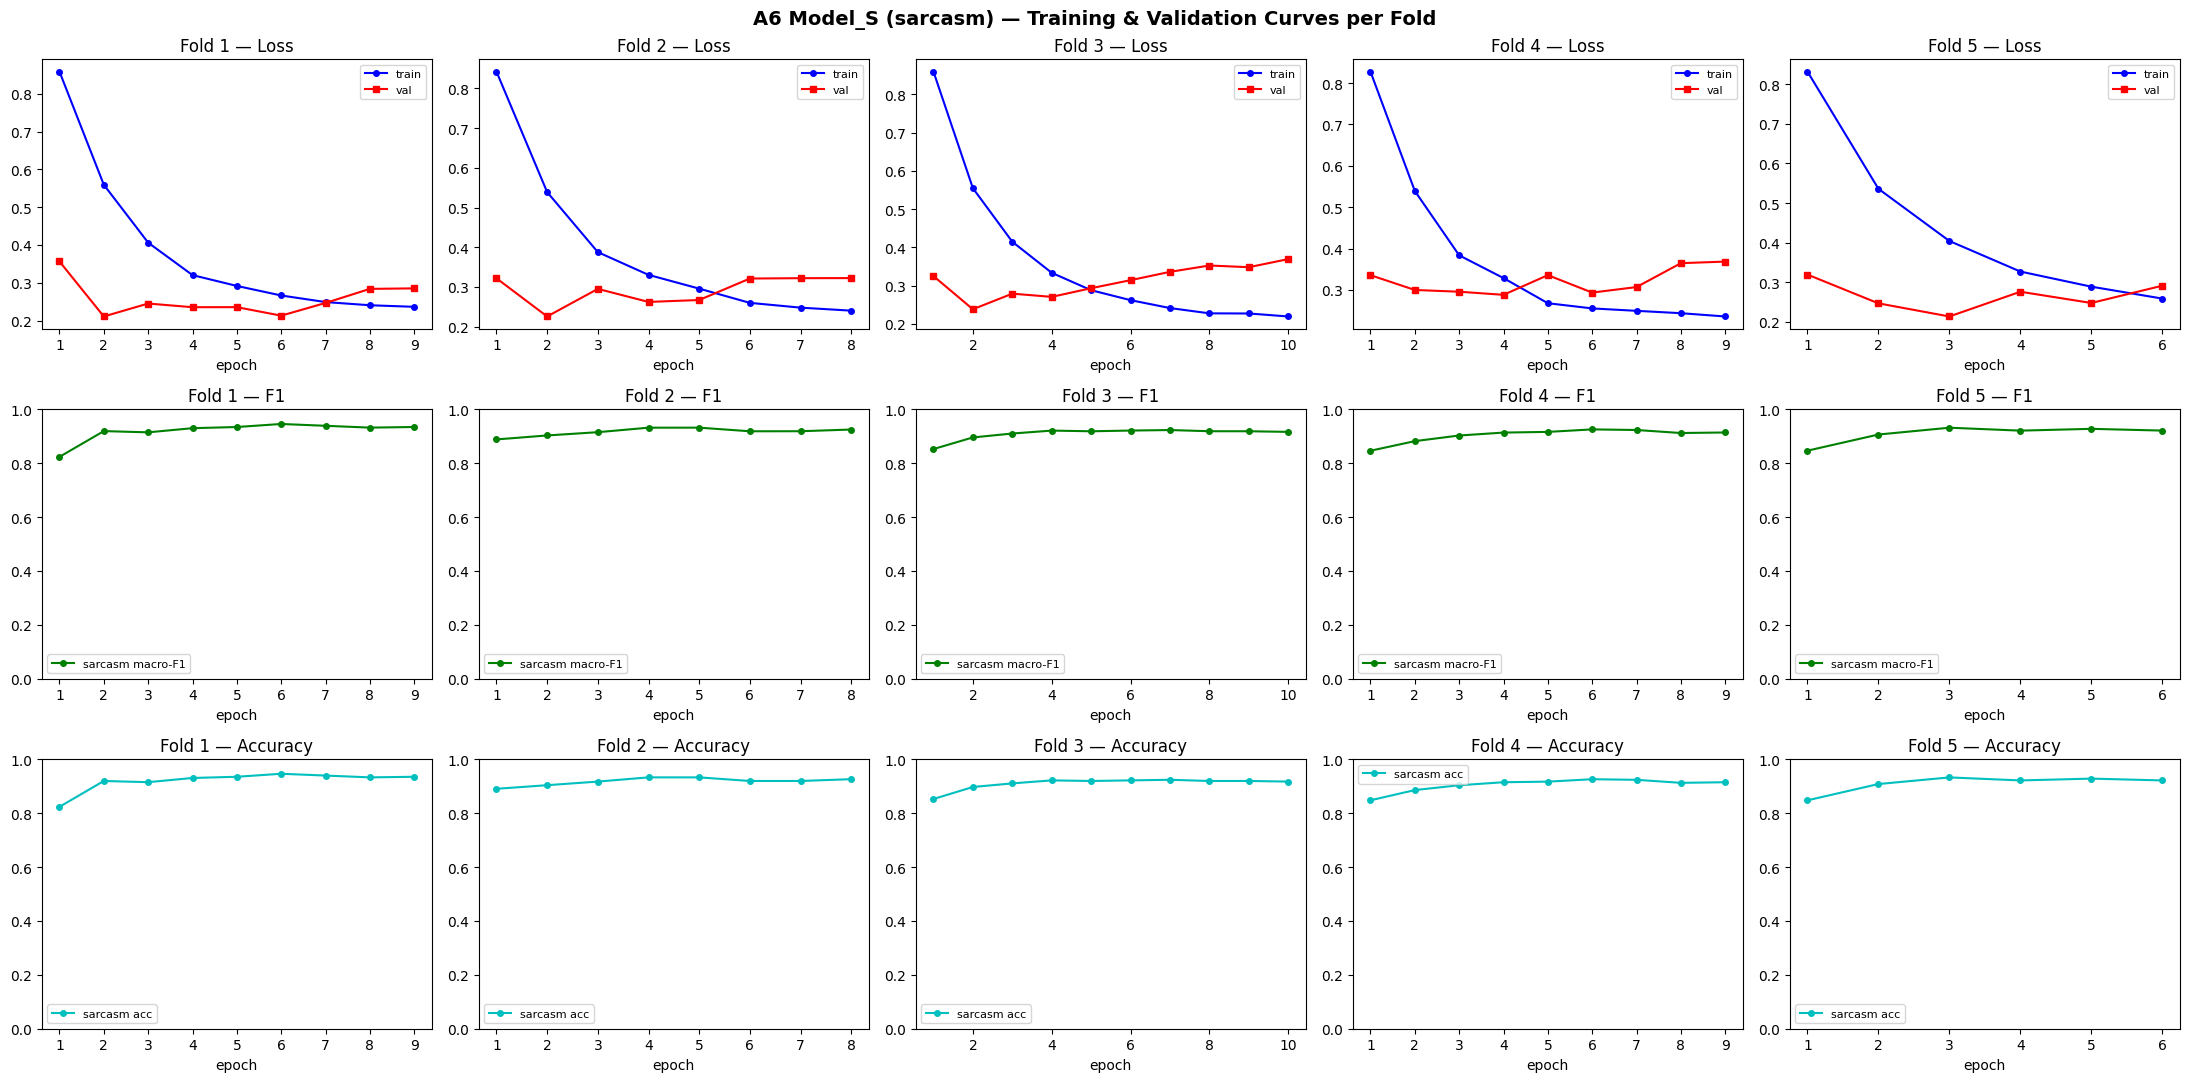

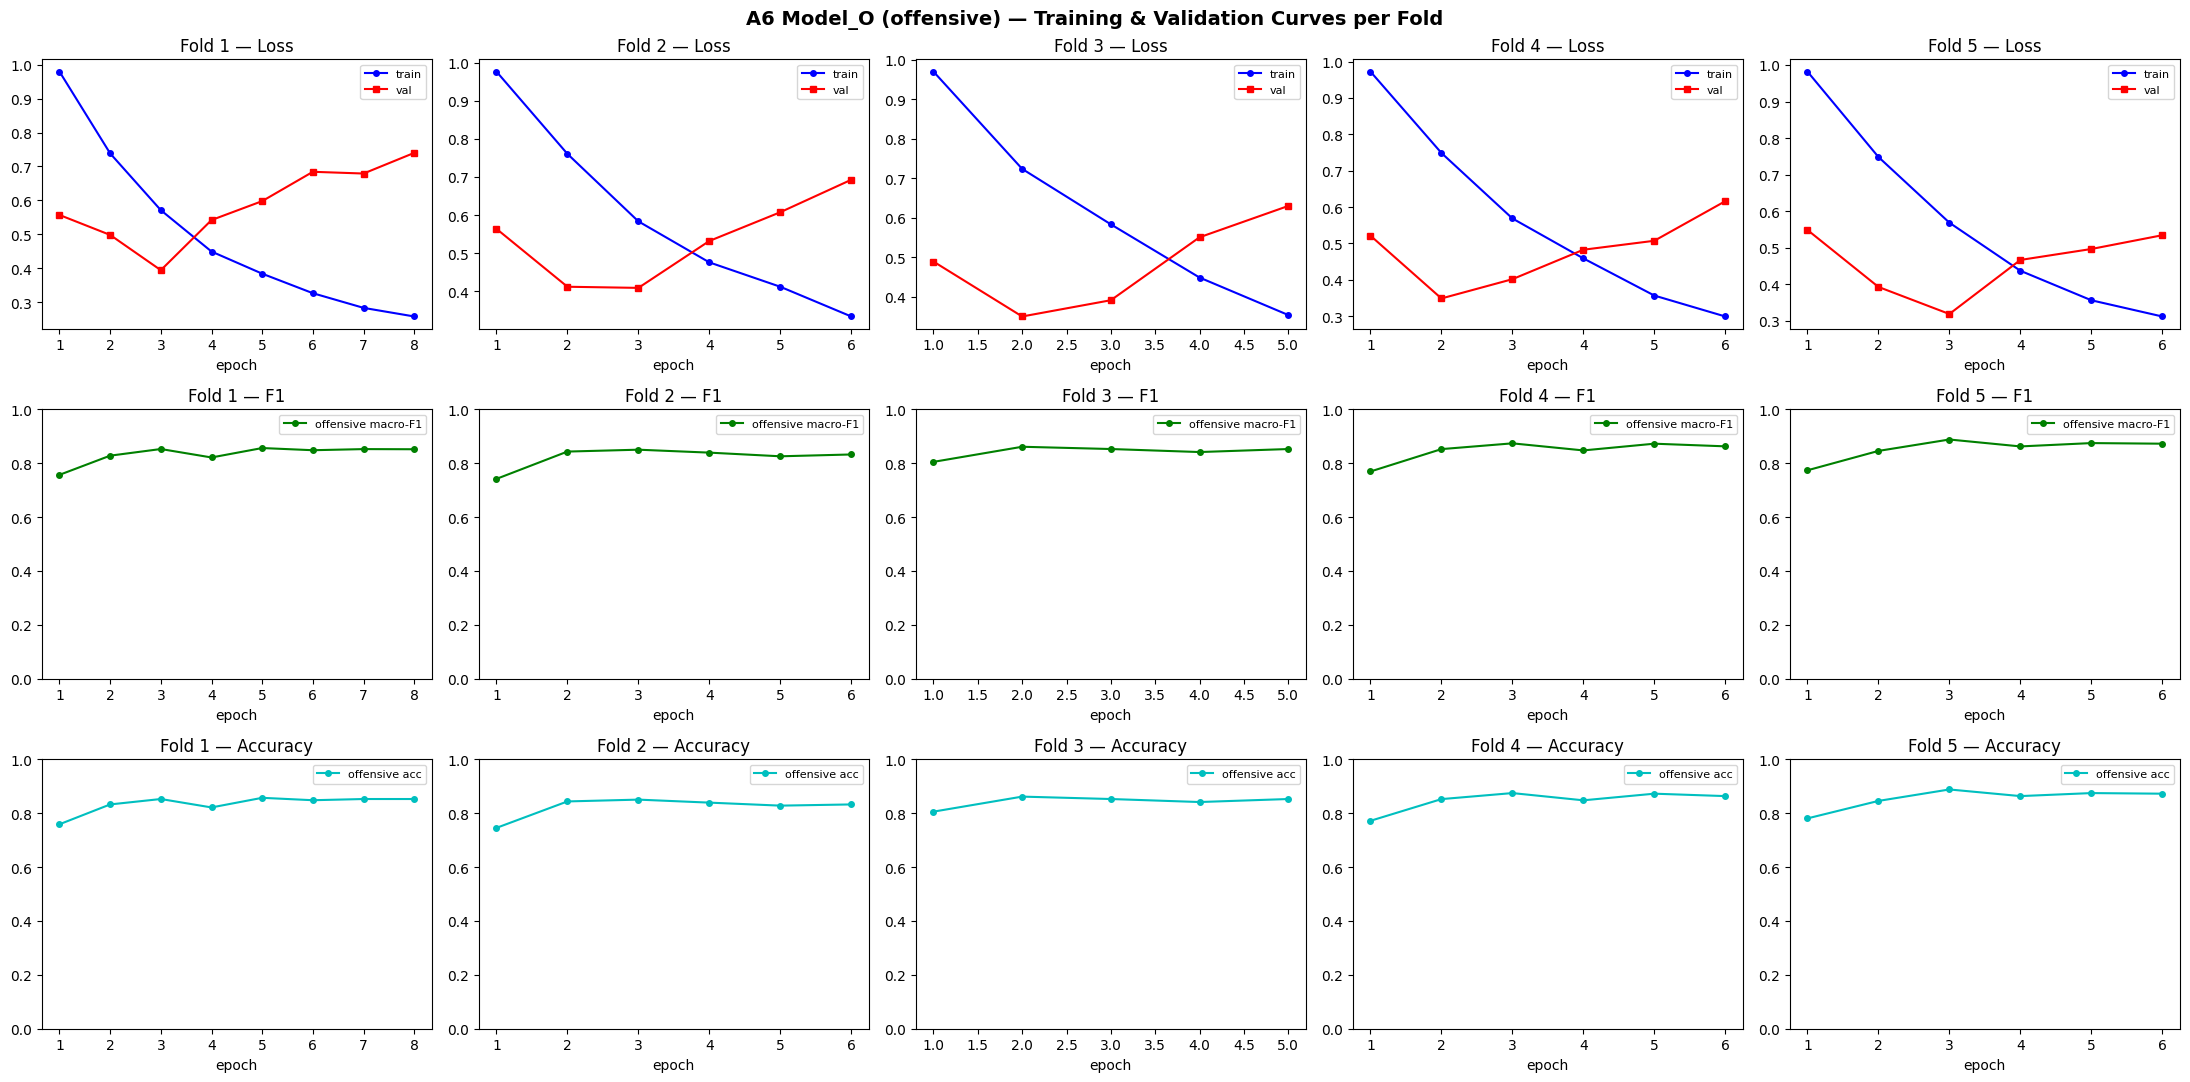

In [16]:
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

for task in A6_TASKS:
    hist = a6_cv[task]["history"]; nF = len(hist)
    mdl  = "Model_S" if task == "sarcasm" else "Model_O"
    fig, axes = plt.subplots(3, nF, figsize=(4.4*nF, 11), squeeze=False)
    fig.suptitle(f"A6 {mdl} ({task}) — Training & Validation Curves per Fold",
                 fontsize=14, fontweight="bold")
    for f, h in hist.items():
        ep = range(1, len(h["train_loss"])+1)
        axes[0][f].plot(ep, h["train_loss"], "b-o", ms=4, label="train")
        axes[0][f].plot(ep, h["val_loss"],   "r-s", ms=4, label="val")
        axes[0][f].set_title(f"Fold {f+1} — Loss"); axes[0][f].legend(fontsize=8); axes[0][f].set_xlabel("epoch")
        axes[1][f].plot(ep, h["f1"], "g-o", ms=4, label=f"{task} macro-F1")
        axes[1][f].set_title(f"Fold {f+1} — F1"); axes[1][f].set_ylim(0,1); axes[1][f].legend(fontsize=8); axes[1][f].set_xlabel("epoch")
        axes[2][f].plot(ep, h["acc"], "c-o", ms=4, label=f"{task} acc")
        axes[2][f].set_title(f"Fold {f+1} — Accuracy"); axes[2][f].set_ylim(0,1); axes[2][f].legend(fontsize=8); axes[2][f].set_xlabel("epoch")
    plt.tight_layout()
    plt.savefig(f"training_curves_a6_{task}.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 13 — Hold-out Evaluation: Stacked Predictions from Two 5-Fold **Ensembles**

Each single-task model is deployed as the mean of its five fold models' sigmoid probabilities
(each fold model paired with **its own fold-fitted, single-task-conditioned intent encoder**,
so the ensembles remain leakage-free). The **combined joint evaluation protocol** then:

1. loads predictions from **both** `Model_S` and `Model_O` on the hold-out test set;
2. reports **per-task** classification reports (Precision, Recall, F1, AUC, MCC);
3. **stacks** the binary predictions into `[Pred_Sarcasm, Pred_Offensive]` and computes the
   **joint multi-label metrics**: Exact Match Ratio (subset accuracy), Hamming Loss, Jaccard
   index (samples / micro / macro), and micro/macro-F1 across the joint outcomes.

In [17]:
# Section 13 — Hold-out evaluation via two stacked single-task 5-fold ensembles

# --- Resume-safe reload of both phases if a6_cv is not in memory ---------------
REF_SEED = CFG["ABLATION_SEED"]
if 'a6_cv' not in dir():
    a6_cv = {}
    for task in ["sarcasm", "offensive"]:
        ck_path = os.path.join(CFG["RUN_DIR"], f"a6_{task}_seed{REF_SEED}.pt")
        if not os.path.exists(ck_path):
            raise FileNotFoundError(f"No A6 checkpoint at {ck_path}. Run Section 12 first.")
        ck = torch.load(ck_path, map_location="cpu", weights_only=False)
        a6_cv[task] = {"task": task, "models": [m.to("cpu") for m in ck["models"]],
                       "encoders": ck["encoders"], "metrics": ck["metrics"],
                       "history": ck["history"], "fold_indices": ck["fold_indices"]}
    A6_TASKS = ["sarcasm", "offensive"]
    print("A6 checkpoints loaded for both tasks.")

# --- Single-task ensemble prediction -------------------------------------------
def ensemble_predict_single_task(models, encoders, raw_texts, max_len=None,
                                 batch_size=32, preprocess_fn=None):
    """Mean sigmoid prob across SINGLE-HEAD fold models; each uses its own fitted
    (single-task-conditioned) intent encoder. Returns one probability array."""
    max_len = CFG["MAX_LEN"] if max_len is None else max_len
    pp = preprocess if preprocess_fn is None else preprocess_fn
    exp = [pp(t) for t in raw_texts]
    p_sum = np.zeros(len(raw_texts))
    for m, enc in zip(models, encoders):
        m.to(DEVICE).eval()
        feats = torch.tensor(enc.transform(raw_texts), dtype=torch.float32)
        for i in range(0, len(raw_texts), batch_size):
            chunk = exp[i:i+batch_size]
            t = tokenizer(chunk, max_length=max_len, padding="max_length",
                          truncation=True, return_tensors="pt")
            with torch.no_grad():
                logit = m(t["input_ids"].to(DEVICE), t["attention_mask"].to(DEVICE),
                          feats[i:i+batch_size].to(DEVICE))
            p_sum[i:i+batch_size] += torch.sigmoid(logit).cpu().numpy()
        m.to("cpu")
    return p_sum / len(models)

def a6_predict(raw_texts, cv_s=None, cv_o=None, preprocess_fn=None, batch_size=32):
    """Joint A6 prediction: run BOTH independent ensembles and return (P_sarc, P_off)."""
    cv_s = a6_cv["sarcasm"]   if cv_s is None else cv_s
    cv_o = a6_cv["offensive"] if cv_o is None else cv_o
    ps = ensemble_predict_single_task(cv_s["models"], cv_s["encoders"], list(raw_texts),
                                      batch_size=batch_size, preprocess_fn=preprocess_fn)
    po = ensemble_predict_single_task(cv_o["models"], cv_o["encoders"], list(raw_texts),
                                      batch_size=batch_size, preprocess_fn=preprocess_fn)
    return ps, po

# --- Get test labels -----------------------------------------------------------
sarc_true = df_test.sarcasm.values
off_true  = df_test.offensive.values

# --- Generate stacked A6 predictions on the hold-out test set ------------------
sarc_prob, off_prob = a6_predict(df_test.text.values)
sarc_pred, off_pred = (sarc_prob >= .5).astype(int), (off_prob >= .5).astype(int)

# --- Combined joint evaluation protocol ----------------------------------------
def _report(tag, sp_prob, op_prob):
    spd, opd = (sp_prob >= .5).astype(int), (op_prob >= .5).astype(int)
    print("="*62); print(f"  HOLD-OUT TEST — {tag}"); print("="*62)
    print("\n── Sarcasm (Model_S) ──")
    print(classification_report(sarc_true, spd, target_names=["Non-Sarc","Sarc"], digits=4))
    print("── Offensive (Model_O) ──")
    print(classification_report(off_true, opd, target_names=["Non-Off","Off"], digits=4))
    yt = np.stack([sarc_true, off_true], 1); yp = np.stack([spd, opd], 1)
    print("── Joint multi-label (stacked [Pred_Sarcasm, Pred_Offensive]) ──")
    print(f"  Exact Match Ratio : {np.all(yt==yp, axis=1).mean():.4f}")
    print(f"  Hamming Loss      : {hamming_loss(yt, yp):.4f}")
    print(f"  Jaccard (samples) : {jaccard_score(yt, yp, average='samples'):.4f}")
    print(f"  Jaccard (micro)   : {jaccard_score(yt, yp, average='micro'):.4f}")
    print(f"  Jaccard (macro)   : {jaccard_score(yt, yp, average='macro'):.4f}")
    print(f"  Joint micro-F1    : {f1_score(yt, yp, average='micro', zero_division=0):.4f}")
    print(f"  Joint macro-F1    : {f1_score(yt, yp, average='macro', zero_division=0):.4f}")
    print(f"  Sarc MCC / AUC    : {matthews_corrcoef(sarc_true, spd):.4f} / {roc_auc_score(sarc_true, sp_prob):.4f}")
    print(f"  Off  MCC / AUC    : {matthews_corrcoef(off_true, opd):.4f} / {roc_auc_score(off_true, op_prob):.4f}")

_report("BASELINE A6 — STACKED SINGLE-TASK ENSEMBLES (unseen data)", sarc_prob, off_prob)

  HOLD-OUT TEST — BASELINE A6 — STACKED SINGLE-TASK ENSEMBLES (unseen data)

── Sarcasm (Model_S) ──
              precision    recall  f1-score   support

    Non-Sarc     0.8619    0.9070    0.8839       172
        Sarc     0.9252    0.8879    0.9062       223

    accuracy                         0.8962       395
   macro avg     0.8936    0.8974    0.8950       395
weighted avg     0.8976    0.8962    0.8965       395

── Offensive (Model_O) ──
              precision    recall  f1-score   support

     Non-Off     0.8443    0.8775    0.8606       204
         Off     0.8634    0.8272    0.8449       191

    accuracy                         0.8532       395
   macro avg     0.8539    0.8523    0.8527       395
weighted avg     0.8536    0.8532    0.8530       395

── Joint multi-label (stacked [Pred_Sarcasm, Pred_Offensive]) ──
  Exact Match Ratio : 0.7899
  Hamming Loss      : 0.1253
  Jaccard (samples) : 0.7354
  Jaccard (micro)   : 0.7824
  Jaccard (macro)   : 0.7800
  Joint m

## Section 13b — Confusion Matrices & ROC Curves (hold-out, stacked A6 ensembles)

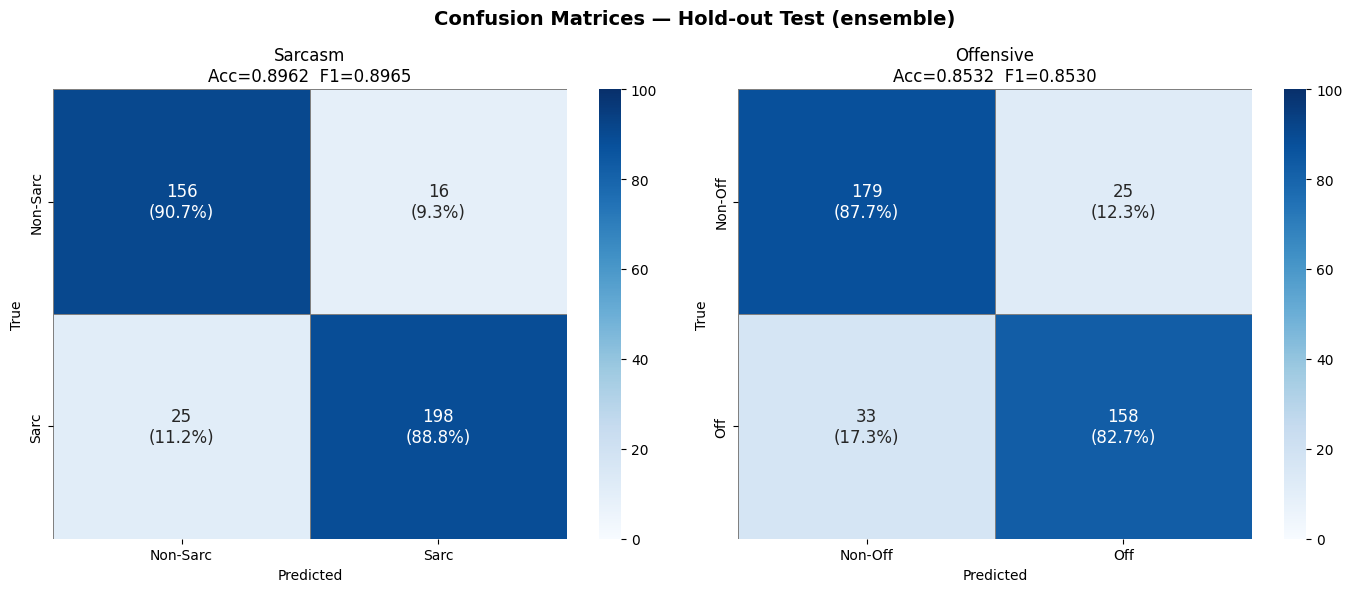

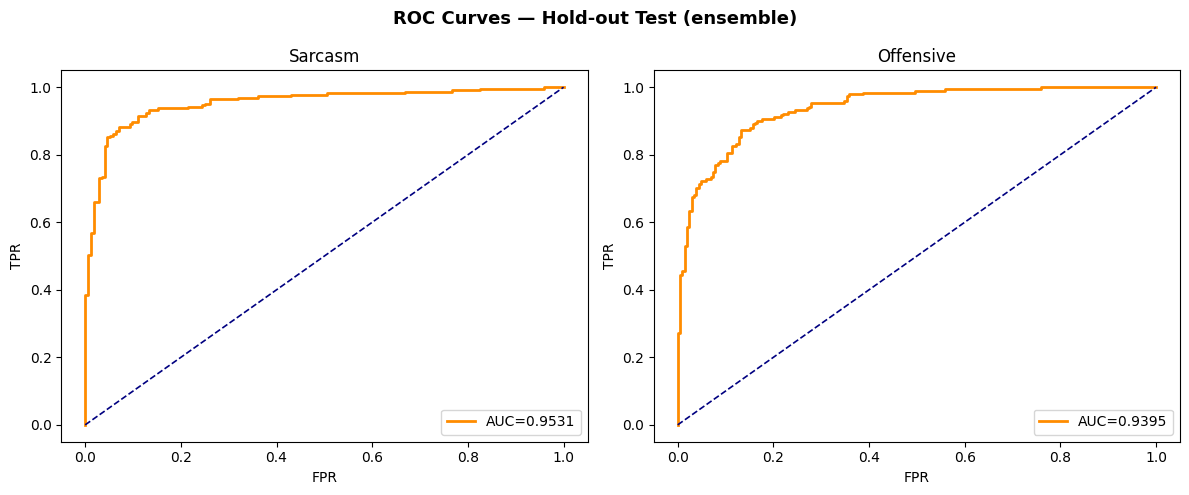

In [18]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Confusion Matrices — Hold-out Test (ensemble)", fontsize=14, fontweight="bold")
for ax, (yt_, yp_, title, labels) in zip(axes, [
        (sarc_true, sarc_pred, "Sarcasm", ["Non-Sarc","Sarc"]),
        (off_true,  off_pred,  "Offensive", ["Non-Off","Off"])]):
    cm = confusion_matrix(yt_, yp_); pct = cm/cm.sum(1, keepdims=True)*100
    annot = np.array([[f"{cm[i,j]}\n({pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
    sns.heatmap(pct, annot=annot, fmt="", cmap="Blues", xticklabels=labels, yticklabels=labels,
                ax=ax, vmin=0, vmax=100, linewidths=.5, linecolor="gray", annot_kws={"size":12})
    ax.set_title(f"{title}\nAcc={accuracy_score(yt_,yp_):.4f}  "
                 f"F1={f1_score(yt_,yp_,average='weighted',zero_division=0):.4f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("ROC Curves — Hold-out Test (ensemble)", fontsize=13, fontweight="bold")
for ax, (yt_, pb_, title) in zip(axes, [(sarc_true, sarc_prob, "Sarcasm"),
                                        (off_true, off_prob, "Offensive")]):
    fpr, tpr, _ = roc_curve(yt_, pb_); ax.plot(fpr, tpr, "darkorange", lw=2, label=f"AUC={auc(fpr,tpr):.4f}")
    ax.plot([0,1],[0,1],"navy",ls="--",lw=1.2); ax.set_title(f"{title}"); ax.legend(loc="lower right")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
plt.tight_layout(); plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 13c — Probability Calibration (reliability, ECE/Brier/NLL, temperature scaling)

A high macro-F1 doesn't guarantee the predicted probabilities are *trustworthy*. Here we
quantify calibration of the deployed ensemble on the hold-out test set — Expected/Maximum
Calibration Error (ECE/MCE), Brier score and NLL — and draw reliability diagrams for both
tasks. We then fit a single **temperature** per task on **out-of-fold train/CV predictions**
(leakage-free — the test set is never used to fit T) and report the post-calibration
improvement on test. Calibration is reported for the positive-class probability P(y=1),
the score that thresholding and the ROC curves in 13b actually use.

Fitted temperatures (on OOF train/CV, leakage-free): T_sarc=1.758  T_off=1.549

=== CALIBRATION ON HOLD-OUT TEST (Baseline A6) ===

── Sarcasm ──
  A6 raw        : ECE=0.0683 MCE=0.6129 Brier=0.0823 NLL=0.3449
  A6 +temp.     : ECE=0.0352 MCE=0.3331 Brier=0.0773 NLL=0.2769

── Offensive ──
  A6 raw        : ECE=0.0523 MCE=0.3394 Brier=0.1034 NLL=0.3357
  A6 +temp.     : ECE=0.0524 MCE=0.1497 Brier=0.1017 NLL=0.3391


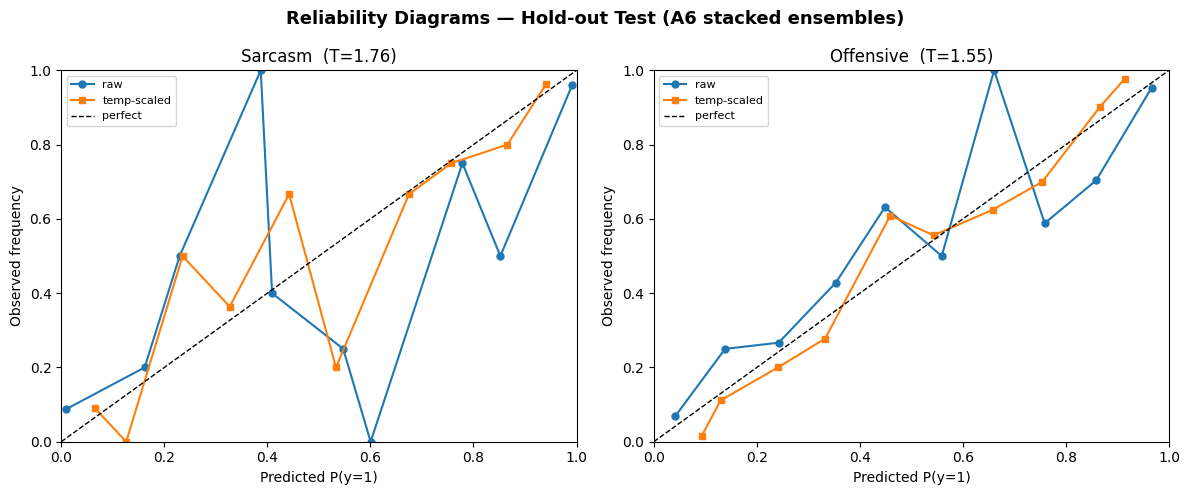

In [19]:
# Section 13c — Probability Calibration (reliability, ECE/Brier/NLL, temperature scaling)

from scipy.optimize import minimize_scalar

# ---- calibration metrics (positive-class P(y=1)) ------------------------------
def calib_bins(y, p, n_bins=10):
    y = np.asarray(y); p = np.asarray(p)
    edges = np.linspace(0, 1, n_bins + 1)
    conf = np.full(n_bins, np.nan); acc = np.full(n_bins, np.nan); wt = np.zeros(n_bins)
    idx = np.clip(np.digitize(p, edges[1:-1]), 0, n_bins - 1)
    for b in range(n_bins):
        m = idx == b
        if m.any():
            conf[b] = p[m].mean(); acc[b] = y[m].mean(); wt[b] = m.mean()
    return edges, conf, acc, wt

def calib_scores(y, p, n_bins=10):
    _, conf, acc, wt = calib_bins(y, p, n_bins)
    ok = ~np.isnan(conf)
    ece = float(np.sum(wt[ok] * np.abs(acc[ok] - conf[ok])))
    mce = float(np.max(np.abs(acc[ok] - conf[ok]))) if ok.any() else float("nan")
    y = np.asarray(y); pc = np.clip(np.asarray(p), 1e-6, 1 - 1e-6)
    brier = float(np.mean((pc - y) ** 2))
    nll = float(-np.mean(y * np.log(pc) + (1 - y) * np.log(1 - pc)))
    return {"ECE": ece, "MCE": mce, "Brier": brier, "NLL": nll}

# ---- temperature scaling on ensemble probabilities ----------------------------
def _logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def _apply_T(p, T):
    return 1.0 / (1.0 + np.exp(-_logit(p) / T))

def _fit_T(p_val, y_val):
    z = _logit(p_val)
    def nll(T):
        q = np.clip(1.0 / (1.0 + np.exp(-z / T)), 1e-6, 1 - 1e-6)
        return -np.mean(y_val * np.log(q) + (1 - y_val) * np.log(1 - q))
    return float(minimize_scalar(nll, bounds=(0.05, 10.0), method="bounded").x)

# ---- leakage-free OOF validation probs from the A6 fold models ----------------
# Each pool example is scored by the fold model for which it was in the VALIDATION
# split -> genuine held-out predictions, no test data used. Each task uses its OWN
# independent fold models & single-task encoders.
oof_sarc = np.full(len(df_trainval), np.nan)
oof_off  = np.full(len(df_trainval), np.nan)
for f, (a, b) in enumerate(a6_cv["sarcasm"]["fold_indices"]):
    oof_sarc[b] = ensemble_predict_single_task(
        [a6_cv["sarcasm"]["models"][f]], [a6_cv["sarcasm"]["encoders"][f]],
        df_trainval.text.values[b])
for f, (a, b) in enumerate(a6_cv["offensive"]["fold_indices"]):
    oof_off[b] = ensemble_predict_single_task(
        [a6_cv["offensive"]["models"][f]], [a6_cv["offensive"]["encoders"][f]],
        df_trainval.text.values[b])
y_sarc_tv, y_off_tv = df_trainval.sarcasm.values, df_trainval.offensive.values

T_sarc = _fit_T(oof_sarc, y_sarc_tv)
T_off  = _fit_T(oof_off,  y_off_tv)
print(f"Fitted temperatures (on OOF train/CV, leakage-free): "
      f"T_sarc={T_sarc:.3f}  T_off={T_off:.3f}\n")

# ---- calibrate the A6 test ensembles (same model family as the OOF fit) -------
sarc_prob_cal = _apply_T(sarc_prob, T_sarc)
off_prob_cal  = _apply_T(off_prob,  T_off)

print("=== CALIBRATION ON HOLD-OUT TEST (Baseline A6) ===")
cal_rows = []
for tag, yt, praw, pcal in [("Sarcasm", sarc_true, sarc_prob, sarc_prob_cal),
                            ("Offensive", off_true, off_prob, off_prob_cal)]:
    raw = calib_scores(yt, praw)
    cal = calib_scores(yt, pcal)
    print(f"\n── {tag} ──")
    print(f"  A6 raw        : ECE={raw['ECE']:.4f} MCE={raw['MCE']:.4f} "
          f"Brier={raw['Brier']:.4f} NLL={raw['NLL']:.4f}")
    print(f"  A6 +temp.     : ECE={cal['ECE']:.4f} MCE={cal['MCE']:.4f} "
          f"Brier={cal['Brier']:.4f} NLL={cal['NLL']:.4f}")
    cal_rows += [{"task": tag, "variant": "a6_raw", **raw},
                 {"task": tag, "variant": "a6_temp", **cal}]

if cal_rows:
    calib_df = pd.DataFrame(cal_rows)
    calib_df.to_csv(os.path.join(CFG["RUN_DIR"], "a6_calibration.csv"), index=False)

# ---- reliability diagrams (raw vs temperature-scaled) -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Reliability Diagrams — Hold-out Test (A6 stacked ensembles)", fontsize=13, fontweight="bold")
for ax, (tag, yt, praw, pcal) in zip(axes, [("Sarcasm", sarc_true, sarc_prob, sarc_prob_cal),
                                            ("Offensive", off_true, off_prob, off_prob_cal)]):
    for p, lab, style in [(praw, "raw", "o-"), (pcal, "temp-scaled", "s-")]:
        _, conf, acc, _ = calib_bins(yt, p, 10); ok = ~np.isnan(conf)
        ax.plot(conf[ok], acc[ok], style, ms=5, label=lab)
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
    ax.set_title(f"{tag}  (T={T_sarc if tag=='Sarcasm' else T_off:.2f})")
    ax.set_xlabel("Predicted P(y=1)"); ax.set_ylabel("Observed frequency")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("calibration_reliability.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 13d — Robustness to Input Perturbations

We probe how stable the model is under realistic, mostly meaning-preserving perturbations
of the hold-out inputs, all evaluated with the Run-1 ensemble on identical labels:

* **emoji_drop** — all emojis removed (text *and* intent vector lose the signal): expected
  degradation, quantifying how much the model relies on emojis (ties to the core thesis).
* **emoji_swap_in** — one emoji swapped for a sibling in the *same* intent cluster
  (meaning-preserving): predictions should be **stable** (low flip-rate, small ΔF1).
* **emoji_swap_cross** — one emoji swapped for a *different*-cluster emoji (distractor):
  measures spurious sensitivity.
* **emoji_repeat** — existing emojis tripled (🤣→🤣🤣🤣): intensity robustness.
* **char_typo** — character-level noise on Bangla text with emojis preserved: text robustness.

For each we report macro-F1 per task, Δ vs clean, and the **prediction flip-rate** (share of
examples whose predicted label changed vs clean), overall and on emoji-bearing rows. All
perturbations are seeded for reproducibility.

=== ROBUSTNESS TO INPUT PERTURBATIONS (A6 stacked ensembles, hold-out) ===
    perturbation  sarc_macroF1  off_macroF1   Δsarc    Δoff  flip%_all  flip%_emoji_rows
           clean        0.8950       0.8527  0.0000  0.0000     0.0000            0.0000
      emoji_drop        0.6608       0.7473 -0.2342 -0.1055    43.0380           43.5897
   emoji_swap_in        0.8899       0.8422 -0.0051 -0.0106     7.3418            7.4359
emoji_swap_cross        0.6533       0.7417 -0.2417 -0.1111    42.7848           43.3333
 emoji_repeat_x3        0.8483       0.7474 -0.0468 -0.1054    25.0633           25.3846
       char_typo        0.8870       0.8581 -0.0080  0.0053     9.8734            9.4872


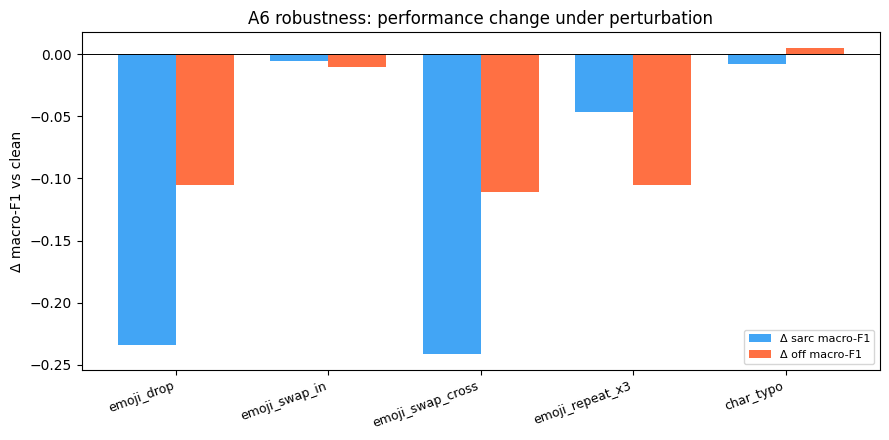


Reading the table: emoji_drop should show the LARGEST drop (models use emoji signal);
emoji_swap_in / char_typo should show SMALL ΔF1 + low flip-rate (meaning-preserving → robust);
emoji_swap_cross probes spurious sensitivity to a distractor emoji.


In [20]:
# Section 13d — Robustness to Input Perturbations (A6 stacked ensembles)

rob_rng = random.Random(SEED)

def perturb_emoji_drop(t):   return strip_emojis(t)
def perturb_emoji_swap_in(t): return augment_emoji_substitution(t, p=1.0, rng=rob_rng)  # in-cluster

def perturb_emoji_swap_cross(t):
    chars = list(str(t)); pos = [i for i, c in enumerate(chars) if c in EMOJI_TO_CLUSTER]
    if not pos: return t
    i = rob_rng.choice(pos); cur = chars[i]
    same = set(next((cl for cl in CLUSTERS if cur in cl), []))
    other = [c for cl in CLUSTERS for c in cl if c not in same]
    if other: chars[i] = rob_rng.choice(other)
    return "".join(chars)

def perturb_emoji_repeat(t, k=3):
    return "".join(c * (k if c in emojilib.EMOJI_DATA else 1) for c in str(t))

def perturb_typo(t, p=0.08):
    out = []
    for c in str(t):
        if c in emojilib.EMOJI_DATA: out.append(c); continue
        r = rob_rng.random()
        if r < p * 0.5:      continue                 # drop char
        elif r < p:          out.append(c); out.append(c)   # duplicate char
        else:                out.append(c)
    return "".join(out)

def eval_perturbation(texts):
    # Both independent single-task ensembles score the perturbed inputs.
    ps, po = a6_predict(list(texts))
    return {"sarc_pred": (ps >= .5).astype(int), "off_pred": (po >= .5).astype(int),
            "sarc_f1": f1_score(sarc_true, (ps >= .5).astype(int), average="macro", zero_division=0),
            "off_f1":  f1_score(off_true,  (po >= .5).astype(int), average="macro", zero_division=0)}

clean_texts = list(df_test.text.values)
has_emoji   = np.array([len(extract_emojis(t)) > 0 for t in clean_texts])
base        = eval_perturbation(clean_texts)
base_sp, base_op = base["sarc_pred"], base["off_pred"]

PERTS = [("emoji_drop",        [perturb_emoji_drop(t)       for t in clean_texts]),
         ("emoji_swap_in",     [perturb_emoji_swap_in(t)    for t in clean_texts]),
         ("emoji_swap_cross",  [perturb_emoji_swap_cross(t) for t in clean_texts]),
         ("emoji_repeat_x3",   [perturb_emoji_repeat(t)     for t in clean_texts]),
         ("char_typo",         [perturb_typo(t)             for t in clean_texts])]

rows = [{"perturbation": "clean", "sarc_macroF1": base["sarc_f1"], "off_macroF1": base["off_f1"],
         "Δsarc": 0.0, "Δoff": 0.0, "flip%_all": 0.0, "flip%_emoji_rows": 0.0}]
for name, texts in PERTS:
    r = eval_perturbation(texts)
    changed = (r["sarc_pred"] != base_sp) | (r["off_pred"] != base_op)
    flip_all = changed.mean() * 100
    flip_em  = changed[has_emoji].mean() * 100 if has_emoji.any() else float("nan")
    rows.append({"perturbation": name, "sarc_macroF1": r["sarc_f1"], "off_macroF1": r["off_f1"],
                 "Δsarc": r["sarc_f1"] - base["sarc_f1"], "Δoff": r["off_f1"] - base["off_f1"],
                 "flip%_all": flip_all, "flip%_emoji_rows": flip_em})

rob_df = pd.DataFrame(rows)
print("=== ROBUSTNESS TO INPUT PERTURBATIONS (A6 stacked ensembles, hold-out) ===")
print(rob_df.round(4).to_string(index=False))
rob_df.to_csv(os.path.join(CFG["RUN_DIR"], "a6_robustness.csv"), index=False)

# ---- ΔF1 bar plot -------------------------------------------------------------
plot_df = rob_df[rob_df.perturbation != "clean"]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(plot_df)); w = 0.38
ax.bar(x - w/2, plot_df["Δsarc"], w, label="Δ sarc macro-F1", color="#42a5f5")
ax.bar(x + w/2, plot_df["Δoff"],  w, label="Δ off macro-F1",  color="#ff7043")
ax.axhline(0, color="k", lw=.7)
ax.set_xticks(x); ax.set_xticklabels(plot_df["perturbation"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Δ macro-F1 vs clean"); ax.set_title("A6 robustness: performance change under perturbation")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("robustness_delta_f1.png", dpi=150, bbox_inches="tight"); plt.show()

print("\nReading the table: emoji_drop should show the LARGEST drop (models use emoji signal);")
print("emoji_swap_in / char_typo should show SMALL ΔF1 + low flip-rate (meaning-preserving → robust);")
print("emoji_swap_cross probes spurious sensitivity to a distractor emoji.")

## Section 14 — Explainability: LIME on the Model's Real (Preprocessed) Input

LIME is run on the **preprocessed** text — the exact emoji-expanded string the model consumes — so attributions reflect the deployed pipeline. Each emoji phrase is kept as **one atomic token** (via a surrogate encoding), and the emoji-intent vector is **held fixed** during perturbation so the explanation isolates the *text-encoder* pathway where emoji tokens live. Emoji vs word tokens are cleanly separable for the quantitative test in Section 19.

*Reviewer Q&A — "Why preprocessed, not raw?"* Explaining raw text would attribute a transformation the model never sees; explaining the true input is faithful to what is actually classified.

In [21]:
from lime.lime_text import LimeTextExplainer

# Stable per-task explainer encoders: fit on the full train/CV pool only (never on
# test labels) and — as everywhere in A6 — conditioned STRICTLY on the target label.
a6_explain_enc = {
    "sarcasm":   EmojiIntentEncoder().fit(df_trainval.text.values,
                                          df_trainval.sarcasm.values,
                                          df_trainval.sarcasm.values),
    "offensive": EmojiIntentEncoder().fit(df_trainval.text.values,
                                          df_trainval.offensive.values,
                                          df_trainval.offensive.values),
}
# Descriptive corpus encoder (BOTH labels) — used ONLY for the analysis figures in
# Sections 17–18 (ambiguity score, emoji-intent space); it never feeds any model.
explain_encoder = EmojiIntentEncoder().fit(
    df_trainval.text.values, df_trainval.sarcasm.values, df_trainval.offensive.values)

# --- LIME operates on PREPROCESSED text (the exact format the models were trained on) ---
# Emoji phrases are multi-word (e.g. "[ব্যঙ্গাত্মক হাসি]").  To keep each phrase a single,
# perturbable LIME token, internal spaces are swapped for NUL ("\x00") to form a
# "surrogate" string; the predict_fn restores them before tokenising for the model.
def _units(exp_text):
    """Split preprocessed text into units; bracketed emoji phrases stay atomic."""
    toks, units, buf = exp_text.split(" "), [], []
    for t in toks:
        if buf:
            buf.append(t)
            if t.endswith("]"): units.append(" ".join(buf)); buf = []
        elif t.startswith("[") and not t.endswith("]"):
            buf = [t]
        else:
            units.append(t)
    if buf: units.append(" ".join(buf))
    return [u for u in units if u]

def to_surrogate(exp_text):
    return " ".join(u.replace(" ", "\x00") for u in _units(exp_text))

def is_emoji_token(tok):
    """Emoji-phrase tokens are the bracketed units produced by expand_emojis()."""
    return tok.strip().startswith("[")

def make_lime_predict_fn_pre(models, intent_vec, task="sarcasm"):
    """LIME predict_fn over surrogate (preprocessed) strings for SINGLE-HEAD models.
    The intent vector is held FIXED at the original example's value (it cannot be
    re-derived once emojis are perturbed), so LIME attributes the TEXT-ENCODER
    pathway — exactly where the emoji-phrase tokens live. `models` must be the fold
    models of the ensemble responsible for `task` (Model_S or Model_O)."""
    feat0 = torch.tensor(np.asarray(intent_vec, dtype=np.float32))   # [1,10]
    def predict_fn(surrogate_texts):
        real = [s.replace("\x00", " ") for s in surrogate_texts]
        enc = tokenizer(real, max_length=CFG["MAX_LEN"], padding="max_length",
                        truncation=True, return_tensors="pt")
        feats = feat0.repeat(len(real), 1)
        prob = np.zeros(len(real))
        for m in models:
            m.to(DEVICE).eval()
            with torch.no_grad():
                logit = m(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE), feats.to(DEVICE))
            prob += torch.sigmoid(logit).cpu().numpy(); m.to("cpu")
        prob /= len(models)
        return np.c_[1-prob, prob]
    return predict_fn

# --- Version-robust LIME explainer construction --------------------------------
# Some installed lime builds accept `split_expr`/`bow` as __init__ kwargs and
# some do NOT (that mismatch raised: TypeError ... unexpected keyword 'split_expr').
# We introspect the signature, pass only what is supported, then set the
# tokenisation attributes directly (explain_instance reads them off `self` when it
# builds the IndexedString), so whitespace-only splitting holds on any lime version.
def _make_lime_text_explainer(class_names):
    import inspect
    _params = inspect.signature(LimeTextExplainer.__init__).parameters
    _kwargs = {"class_names": class_names}
    if "split_expr" in _params: _kwargs["split_expr"] = r"\s+"
    if "bow"        in _params: _kwargs["bow"]        = True
    _explainer = LimeTextExplainer(**_kwargs)
    _explainer.split_expr = r"\s+"   # NUL-joined emoji phrases stay atomic (NUL is not \s)
    _explainer.bow        = True
    _explainer.char_level = False
    return _explainer

def lime_explain_pre(raw_text, task, class_names, models=None, num_samples=None, num_features=15):
    models = a6_cv[task]["models"] if models is None else models      # task-matched ensemble
    num_samples = CFG["LIME_SAMPLES"] if num_samples is None else num_samples
    exp_text  = preprocess(raw_text)
    surrogate = to_surrogate(exp_text)
    ivec      = a6_explain_enc[task].transform([raw_text])            # single-task encoder
    fn        = make_lime_predict_fn_pre(models, ivec, task=task)
    explainer = _make_lime_text_explainer(class_names)
    exp = explainer.explain_instance(surrogate, fn, num_features=num_features,
                                     num_samples=num_samples, labels=[1])
    return exp

def lime_features(exp):
    """Return [(readable_token, weight)] with NUL restored to space."""
    return [(feat.replace("\x00", " "), w) for feat, w in exp.as_list(label=1)]

# choose an example WITH emojis from the test set
cand = [i for i in range(len(df_test)) if extract_emojis(df_test.text.iloc[i])]
sidx = cand[0]
raw_example = df_test.text.iloc[sidx]
print(f"Explaining: {raw_example}")
print(f"  preprocessed: {preprocess(raw_example)}")
print(f"  truth: Sarcasm={sarc_true[sidx]}, Offensive={off_true[sidx]}")

Explaining: এই চেহারা নিয়ে চান্স পেল কিভাবে 🙄🙄
  preprocessed: এই চেহারা নিয়ে চান্স পেল কিভাবে [চোখ ঘোরানো] [চোখ ঘোরানো]
  truth: Sarcasm=0, Offensive=1



LIME — sarcasm:
  🔤 এই                           -0.2745
  🔤 হ                            -0.1647
  🔤 য                            -0.1119
  🔤 খ                            +0.0785
  🔤 চ                            -0.0667
  🔤 ক                            -0.0651
  🔤 প                            +0.0411
  🔤 ঘ                            -0.0381
  🔤 ভ                            +0.0365
  🔤 ল                            +0.0314
  🔤 র                            +0.0252
  🔤 ব                            +0.0062
  🔤 ন                            -0.0024
  🔤 স                            -0.0005


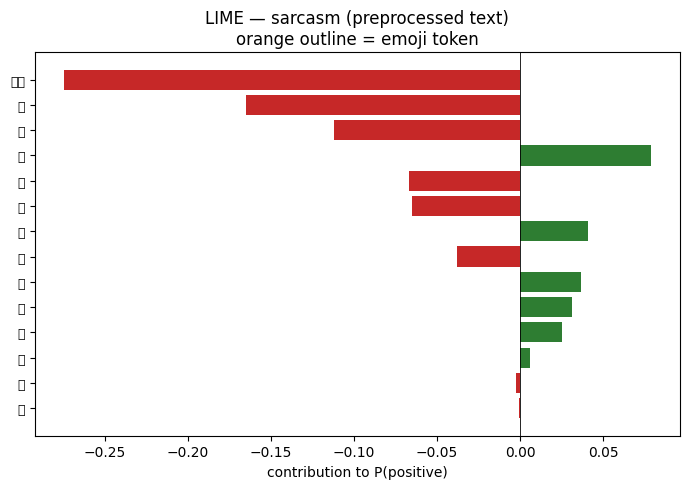


LIME — offensive:
  🔤 চ                            +0.1882
  🔤 এই                           +0.1806
  🔤 ন                            +0.1254
  🔤 হ                            +0.1208
  🔤 ভ                            -0.0936
  🔤 প                            -0.0912
  🔤 য                            +0.0714
  🔤 খ                            +0.0541
  🔤 ক                            +0.0489
  🔤 ল                            +0.0410
  🔤 ঘ                            +0.0269
  🔤 র                            +0.0244
  🔤 ব                            -0.0159
  🔤 স                            -0.0030


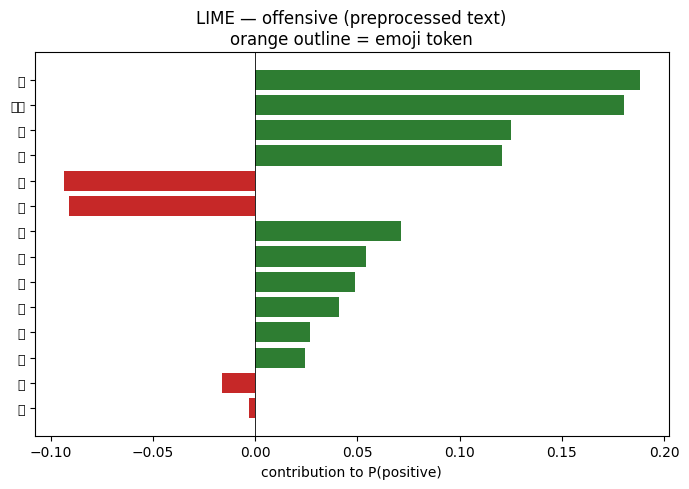

In [22]:
for task, names, png in [("sarcasm", ["Non-Sarc","Sarc"], "lime_sarcasm.png"),
                         ("offensive", ["Non-Off","Off"], "lime_offensive.png")]:
    exp = lime_explain_pre(raw_example, task, names)
    feats = lime_features(exp)
    print(f"\nLIME — {task}:")
    for feat, w in feats:
        print(f"  {'😀' if is_emoji_token(feat) else '🔤'} {feat:<28} {w:+.4f}")
    # readable horizontal bar (green=+, red=-), emoji tokens outlined
    labels = [f for f, _ in feats][::-1]; vals = [w for _, w in feats][::-1]
    colors = ["#2e7d32" if w >= 0 else "#c62828" for w in vals]
    edges  = ["#ff7043" if is_emoji_token(f) else "none" for f in labels]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(range(len(vals)), vals, color=colors, edgecolor=edges, linewidth=2)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color="k", lw=.6); ax.set_title(f"LIME — {task} (preprocessed text)\norange outline = emoji token")
    ax.set_xlabel("contribution to P(positive)")
    plt.tight_layout(); plt.savefig(png, dpi=150, bbox_inches="tight"); plt.show()

## Section 14b — Emoji vs Word Contribution (single example)

For one representative example we contrast the total |LIME weight| carried by emoji tokens vs word tokens, for each task. The **population-level** hypothesis test that emojis contribute more than words (paired *t*-test + Wilcoxon over many examples) is deferred to Section 19.

sarcasm: emoji-mass=0.0000  word-mass=0.9580  emoji-share=0.0%
offensive: emoji-mass=0.0000  word-mass=1.0443  emoji-share=0.0%


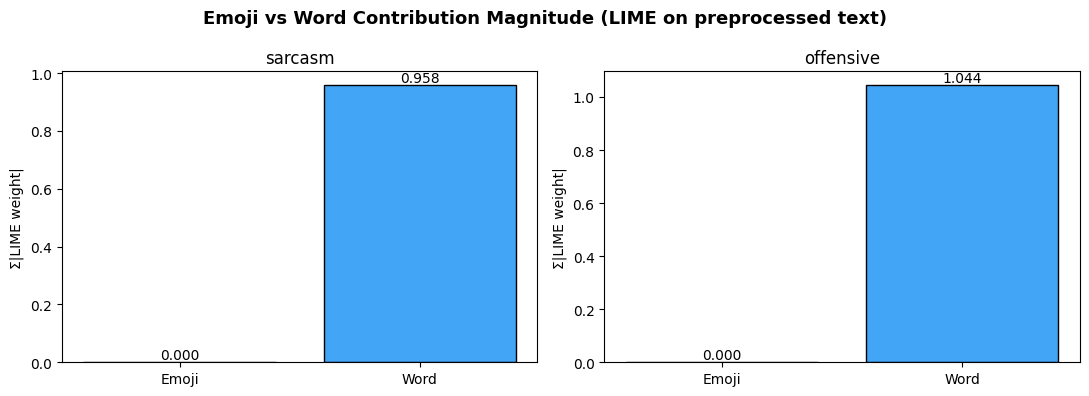


Note: the population-level 'emojis matter' t-test (many examples) is in Section 19.


In [23]:
def emoji_word_split(exp):
    em, wd = [], []
    for feat, w in lime_features(exp):
        (em if is_emoji_token(feat) else wd).append((feat, w))
    return em, wd

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Emoji vs Word Contribution Magnitude (LIME on preprocessed text)", fontsize=13, fontweight="bold")
for ax, (task, names) in zip(axes, [("sarcasm",["Non-Sarc","Sarc"]),("offensive",["Non-Off","Off"])]):
    exp = lime_explain_pre(raw_example, task, names)
    em, wd = emoji_word_split(exp)
    vals = [sum(abs(w) for _, w in em), sum(abs(w) for _, w in wd)]
    bars = ax.bar(["Emoji","Word"], vals, color=["#ff7043","#42a5f5"], edgecolor="k")
    ax.set_title(task); ax.set_ylabel("Σ|LIME weight|")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1e-3, f"{v:.3f}", ha="center", va="bottom")
    share = vals[0]/max(sum(vals),1e-9)*100
    print(f"{task}: emoji-mass={vals[0]:.4f}  word-mass={vals[1]:.4f}  emoji-share={share:.1f}%")
plt.tight_layout(); plt.savefig("lime_emoji_vs_word.png", dpi=150, bbox_inches="tight"); plt.show()
print("\nNote: the population-level 'emojis matter' t-test (many examples) is in Section 19.")

## Section 15 — Robust Inference (`predict_text`) + Interactive Prompt (A6)

A single reusable `predict_text` with full **input validation and error handling** (empty,
over-long, non-Bangla, emoji-only, tokenizer/model failure) that returns a status field
instead of raising. Under A6 it runs **both** independent single-task ensembles — `Model_S`
for `P(sarcasm)` and `Model_O` for `P(offensive)` — each with its own single-task-conditioned
intent encoder, and composes the joint label from the two binary decisions. The interactive
prompt is **enabled by default** and guarded so "Run all" in a non-interactive kernel skips
it cleanly.

In [24]:
BANGLA_RANGE = range(0x0980, 0x0A00)   # Bengali Unicode block
def _has_bangla(t): return any(ord(ch) in BANGLA_RANGE for ch in str(t))

def predict_text(raw_text, models_s=None, models_o=None, enc_s=None, enc_o=None,
                 thr_s=0.5, thr_o=0.5, max_chars=2000):
    """Robust single-text inference for Baseline A6 (two independent ensembles).
    Returns a dict; on bad input returns an 'error'/'warning' field instead of raising."""
    models_s = a6_cv["sarcasm"]["models"]    if models_s is None else models_s
    models_o = a6_cv["offensive"]["models"]  if models_o is None else models_o
    enc_s    = a6_explain_enc["sarcasm"]     if enc_s is None else enc_s
    enc_o    = a6_explain_enc["offensive"]   if enc_o is None else enc_o
    try:
        # --- input validation ---------------------------------------------------
        if raw_text is None or not str(raw_text).strip():
            return {"error": "empty_input", "label": "⛔ EMPTY INPUT",
                    "p_sarcasm": None, "p_offensive": None}
        raw_text = str(raw_text)
        warning = None
        if len(raw_text) > max_chars:                      # very long text -> truncate
            raw_text = raw_text[:max_chars]; warning = f"truncated_to_{max_chars}_chars"
        if not _has_bangla(raw_text):                      # non-Bangla -> still predict, but flag
            warning = (warning + "; " if warning else "") + "no_bangla_characters_detected"

        # --- forward passes (guarded), one per independent ensemble -------------
        exp = preprocess(raw_text)
        enc = tokenizer(exp, max_length=CFG["MAX_LEN"], padding="max_length",
                        truncation=True, return_tensors="pt")

        def _ens_prob(models, ienc):
            feats = torch.tensor(ienc.transform([raw_text]), dtype=torch.float32)
            p = 0.0
            for m in models:
                m.to(DEVICE).eval()
                with torch.no_grad():
                    logit = m(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE),
                              feats.to(DEVICE))
                p += torch.sigmoid(logit).item(); m.to("cpu")
            return p / len(models)

        sp = _ens_prob(models_s, enc_s)     # Model_S -> P(sarcasm)
        op = _ens_prob(models_o, enc_o)     # Model_O -> P(offensive)
    except Exception as e:                                  # tokenizer / model / any failure
        return {"error": f"{type(e).__name__}: {e}", "label": "⛔ INFERENCE ERROR",
                "p_sarcasm": None, "p_offensive": None}

    is_s, is_o = sp >= thr_s, op >= thr_o
    label = ("⚠️ SARCASTIC + OFFENSIVE" if is_s and is_o else
             "😏 SARCASTIC (not offensive)" if is_s else
             "😡 OFFENSIVE (not sarcastic)" if is_o else "✅ NEITHER")
    out = {"raw": raw_text, "expanded": exp, "emojis": extract_emojis(raw_text),
           "p_sarcasm": round(sp, 4), "p_offensive": round(op, 4), "label": label}
    if warning: out["warning"] = warning
    return out

# smoke tests, incl. edge cases (empty / non-Bangla / emoji-only)
for t in ["সে অনেক ভদ্র 🤣", "তুমি একটা গাধা 😡",
          "করিম এর বুদ্ধি প্রশংসনীয় 🤣 😡", "আজকের আবহাওয়া সুন্দর।",
          "", "hello world 🙂", "🤣🤣🤣"]:
    r = predict_text(t)
    tag = r.get("error") or r.get("warning") or ""
    print(f"{r['label']:<32} P(sarc)={r['p_sarcasm']} P(off)={r['p_offensive']} | {t!r} {('['+tag+']') if tag else ''}")

😏 SARCASTIC (not offensive)      P(sarc)=0.9926 P(off)=0.0458 | 'সে অনেক ভদ্র 🤣' 
😡 OFFENSIVE (not sarcastic)      P(sarc)=0.0085 P(off)=0.9759 | 'তুমি একটা গাধা 😡' 
⚠️ SARCASTIC + OFFENSIVE         P(sarc)=0.9926 P(off)=0.9341 | 'করিম এর বুদ্ধি প্রশংসনীয় 🤣 😡' 
✅ NEITHER                        P(sarc)=0.0213 P(off)=0.0353 | 'আজকের আবহাওয়া সুন্দর।' 
⛔ EMPTY INPUT                    P(sarc)=None P(off)=None | '' [empty_input]
✅ NEITHER                        P(sarc)=0.021 P(off)=0.045 | 'hello world 🙂' [no_bangla_characters_detected]
😏 SARCASTIC (not offensive)      P(sarc)=0.9916 P(off)=0.3636 | '🤣🤣🤣' [no_bangla_characters_detected]


In [25]:
# Interactive inference — ENABLED by default. The guard makes "Run all" safe:
# in a non-interactive kernel input() raises, and we skip gracefully.
import sys
ENABLE_INTERACTIVE = True
if ENABLE_INTERACTIVE:
    interactive_ok = hasattr(sys, "stdin") and sys.stdin is not None and sys.stdin.isatty()
    if not interactive_ok:
        print("Interactive prompt is ENABLED but stdin is non-interactive "
              "(e.g. 'Run all' / batch). Skipping the prompt; call predict_text('...') directly.")
    else:
        try:
            txt = input("Enter Bangla text (with/without emojis), or press Enter to skip: ").strip()
            if txt:
                r = predict_text(txt)
                print(r["label"], "| P(sarc)=", r["p_sarcasm"], "P(off)=", r["p_offensive"],
                      ("| ⚠ " + r["warning"]) if r.get("warning") else "")
        except (EOFError, KeyboardInterrupt):
            print("No interactive input available — skipped.")

Interactive prompt is ENABLED but stdin is non-interactive (e.g. 'Run all' / batch). Skipping the prompt; call predict_text('...') directly.


## Section 16 — Task Relationship & Controlled Comparison vs the Multitask Reference

We first quantify the sarcasm–offensive relationship (χ², φ) and report its **direction**:
the association is **negative** (sarcastic texts are *less* often offensive) — precisely the
structured constraint the multitask hypothesis claims cross-stitch sharing can exploit and
that A6, by construction, **cannot** (its two models never see each other's labels or
representations).

We then load the **reference cross-stitch MTL run** from its checkpoint
(`ref_run_seed42.pt`), regenerate its hold-out ensemble predictions, and compare it against
Baseline A6 on **identical folds, hyper-parameters and test set**, using a **paired *t*-test
across folds** on CV macro-F1 (sample-level McNemar and bootstrap Δ-CIs follow in Section 19).

*Reviewer Q&A — "Is A6 a fair disentanglement baseline?"* Yes: A6 shares the backbone,
intent pipeline, SupCon, folds, budget and hyper-parameters with the reference; the only
differences are (a) no cross-stitch sharing and (b) single-task supervision — exactly the
hypothesis under test.

In [26]:
from scipy.stats import chi2_contingency

phi = matthews_corrcoef(df.sarcasm, df.offensive)
chi2, pval, dof, _ = chi2_contingency(pd.crosstab(df.sarcasm, df.offensive))
p_off_given_sarc = df[df.sarcasm==1].offensive.mean()
p_off_given_nsarc = df[df.sarcasm==0].offensive.mean()
direction = "NEGATIVE" if phi < 0 else "POSITIVE"

print("=== TASK RELATIONSHIP ===")
print(f"P(Offensive | Sarcastic)     = {p_off_given_sarc:.3f}")
print(f"P(Offensive | Non-sarcastic) = {p_off_given_nsarc:.3f}")
print(f"Phi (φ via MCC)              = {phi:.4f}   [{direction} association]")
print(f"Chi-square test             = {chi2:.2f} (p = {pval:.2e}, dof={dof})")
print(f"→ Association is statistically significant (p<0.05): {'YES' if pval < 0.05 else 'NO'}.")
print("\nInterpretation: the two tasks are strongly DEPENDENT (χ² highly significant),")
print("so joint multitask modelling is justified. The dependence is NEGATIVE here —")
print("sarcastic texts are LESS likely to be offensive — which is itself a useful signal")
print("the cross-stitch layer can exploit (a shared representation that separates the two).")
# expose for the statistics suite
TASKREL = {"phi": phi, "chi2": chi2, "p": pval, "dof": dof}

=== TASK RELATIONSHIP ===
P(Offensive | Sarcastic)     = 0.319
P(Offensive | Non-sarcastic) = 0.700
Phi (φ via MCC)              = -0.3781   [NEGATIVE association]
Chi-square test             = 374.85 (p = 1.65e-83, dof=1)
→ Association is statistically significant (p<0.05): YES.

Interpretation: the two tasks are strongly DEPENDENT (χ² highly significant),
so joint multitask modelling is justified. The dependence is NEGATIVE here —
sarcastic texts are LESS likely to be offensive — which is itself a useful signal
the cross-stitch layer can exploit (a shared representation that separates the two).


In [27]:
from scipy.stats import ttest_rel
import gc

# ---- A6 per-fold joint macro-F1 (mean of the two single-task fold macro-F1s) ---
a6_sarc_fold_macro = a6_cv["sarcasm"]["metrics"]["sarc_f1_macro"].values
a6_off_fold_macro  = a6_cv["offensive"]["metrics"]["off_f1_macro"].values
a6_fold_macro      = (a6_sarc_fold_macro + a6_off_fold_macro) / 2

# ---- Load the reference multitask (cross-stitch) run for the paired comparison -
REF_AVAILABLE = os.path.exists(REF_CHECKPOINT)
if REF_AVAILABLE:
    print(f"Loading reference MTL checkpoint from {REF_CHECKPOINT}")
    _ref = torch.load(REF_CHECKPOINT, map_location="cpu", weights_only=False)
    ref_models, ref_encoders = _ref["models"], _ref["encoders"]
    ref_metrics_df = _ref["metrics"]
    ref_fold_macro = ref_metrics_df["macro_f1"].values
    del _ref; gc.collect()

    def ensemble_predict_mtl(models, encoders, raw_texts, max_len=None, batch_size=32):
        """Mean sigmoid prob across the reference TWO-HEAD fold models."""
        max_len = CFG["MAX_LEN"] if max_len is None else max_len
        exp = [preprocess(t) for t in raw_texts]
        ps_sum = np.zeros(len(raw_texts)); po_sum = np.zeros(len(raw_texts))
        for m, enc in zip(models, encoders):
            m.to(DEVICE).eval()
            feats = torch.tensor(enc.transform(raw_texts), dtype=torch.float32)
            for i in range(0, len(raw_texts), batch_size):
                chunk = exp[i:i+batch_size]
                t = tokenizer(chunk, max_length=max_len, padding="max_length",
                              truncation=True, return_tensors="pt")
                with torch.no_grad():
                    s, o = m(t["input_ids"].to(DEVICE), t["attention_mask"].to(DEVICE),
                             feats[i:i+batch_size].to(DEVICE))
                ps_sum[i:i+batch_size] += torch.sigmoid(s).cpu().numpy()
                po_sum[i:i+batch_size] += torch.sigmoid(o).cpu().numpy()
            m.to("cpu")
        n = len(models)
        return ps_sum/n, po_sum/n

    ref_sarc_prob, ref_off_prob = ensemble_predict_mtl(ref_models, ref_encoders,
                                                       df_test.text.values)
    ref_sarc_pred = (ref_sarc_prob >= .5).astype(int)
    ref_off_pred  = (ref_off_prob  >= .5).astype(int)

    # sanity: A6 and the reference must share fold indices verbatim
    _same_folds = all(np.array_equal(x[1], y[1])
                      for x, y in zip(ref_folds, a6_cv["sarcasm"]["fold_indices"]))
    print("Fold indices identical (reference vs A6):", _same_folds)

    # ---- Comparison ladder on identical folds (CV macro-F1) --------------------
    print("\n=== CONTROLLED COMPARISON (identical folds, HP & budget — CV macro-F1) ===")
    print(f"  {'A6 Model_S (sarcasm only)':<42} macro-F1 = {a6_sarc_fold_macro.mean():.4f}")
    print(f"  {'A6 Model_O (offensive only)':<42} macro-F1 = {a6_off_fold_macro.mean():.4f}")
    print(f"  {'A6 joint (stacked single-task)':<42} macro-F1 = {a6_fold_macro.mean():.4f}")
    print(f"  {'Reference MTL (Intent+Cross-stitch+SupCon)':<42} macro-F1 = {ref_fold_macro.mean():.4f}")

    # ---- Paired t-test across folds (MTL > A6), one-sided ----------------------
    print("\n=== PAIRED t-TEST across folds (MTL > A6), one-sided ===")
    comparisons = [
        ("joint",     ref_fold_macro, a6_fold_macro),
        ("sarcasm",   ref_metrics_df["sarc_f1_macro"].values, a6_sarc_fold_macro),
        ("offensive", ref_metrics_df["off_f1_macro"].values,  a6_off_fold_macro),
    ]
    for label, ref_v, a6_v in comparisons:
        t, p2 = ttest_rel(ref_v, a6_v)
        p1 = p2/2 if t > 0 else 1 - p2/2
        print(f"  MTL vs A6 [{label:<9}] Δ={ref_v.mean()-a6_v.mean():+.4f} "
              f"| t={t:+.3f} p(1-sided)={p1:.4f}")
    print("\n(Sample-level McNemar tests + bootstrap Δ-CIs on the hold-out set are in Section 19.)")
else:
    print(f"Reference MTL checkpoint not found at {REF_CHECKPOINT}.")
    print("Run the reference multitask notebook first (or copy its checkpoint into RUN_DIR)")
    print("to enable the paired MTL-vs-A6 comparison. A6-only statistics still run below.")
    ref_sarc_prob = ref_off_prob = ref_sarc_pred = ref_off_pred = None
    ref_fold_macro = None
    print("\n=== A6 CV macro-F1 (identical folds & budget) ===")
    print(f"  {'A6 Model_S (sarcasm only)':<42} macro-F1 = {a6_sarc_fold_macro.mean():.4f}")
    print(f"  {'A6 Model_O (offensive only)':<42} macro-F1 = {a6_off_fold_macro.mean():.4f}")
    print(f"  {'A6 joint (stacked single-task)':<42} macro-F1 = {a6_fold_macro.mean():.4f}")

Reference MTL checkpoint not found at /kaggle/working/runs/ref_run_seed42.pt.
Run the reference multitask notebook first (or copy its checkpoint into RUN_DIR)
to enable the paired MTL-vs-A6 comparison. A6-only statistics still run below.

=== A6 CV macro-F1 (identical folds & budget) ===
  A6 Model_S (sarcasm only)                  macro-F1 = 0.9316
  A6 Model_O (offensive only)                macro-F1 = 0.8659
  A6 joint (stacked single-task)             macro-F1 = 0.8987


## Section 17 — Error Analysis (multi-faceted, A6)

Beyond counts we provide: a **continuous emoji-ambiguity score** (correlated with error via
point-biserial *r*), a **joint 4-class multi-label confusion** matrix built from the stacked
`[Pred_Sarcasm, Pred_Offensive]` outputs, **stratified error rates** (emoji presence, text
length, ambiguity bucket, joint class) to explain *why* errors happen, and a **cross-model**
comparison (Jaccard overlap of A6 vs the multitask reference's errors) separating systematic
from model-specific mistakes.

*Reviewer Q&A — "Do you understand the failure modes?"* Errors concentrate in high-ambiguity
emoji contexts and the minority joint class; the A6-vs-MTL overlap shows which errors joint
modelling fixes and which are systematic to the data.

=== ERROR ANALYSIS (hold-out, A6 stacked ensembles) ===
Sarcasm  FN/FP: 25/16   Offensive FN/FP: 33/25

Continuous ambiguity vs error (emoji rows): point-biserial r=+0.130 (p=0.0103)
  mean ambiguity — correct: 0.383 | wrong: 0.459

── Joint (multi-label) confusion — rows=true, cols=pred ──
col_0       Clean  Abuse  Sarc  Sarc+Abuse
row_0                                     
Clean          44      2     6           0
Abuse           5    105     5           5
Sarc            9     10   120          13
Sarc+Abuse      1      5    22          43


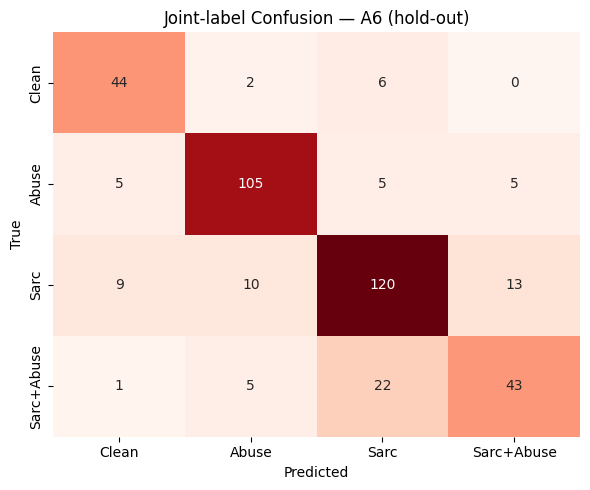


── Error rate by stratum (any-label error) ──
  By emoji presence:
    emoji=False:  20.0% (n=5)
    emoji=True :  21.0% (n=390)
  By text length:
    short:  30.3% (n=132)
    med  :  20.6% (n=131)
    long :  12.1% (n=132)
  By emoji-ambiguity bucket:
    no-emoji:  16.7% (n=36)
    low     :  11.4% (n=105)
    mid     :  27.1% (n=203)
    high    :  19.6% (n=51)
  By true joint class:
    Abuse      : sarc-err   8.3% (n=120) | off-err   8.3% (n=120)
    Clean      : sarc-err  11.5% (n=52) | off-err   3.8% (n=52)
    Sarc       : sarc-err  12.5% (n=152) | off-err  15.1% (n=152)
    Sarc+Abuse : sarc-err   8.5% (n=71) | off-err  32.4% (n=71)

Sample missed sarcasm:
   ঘুমাতে পারিনা সারারাত ধরে, বুকের ভেতর টা হাহাকার করে 😭
   তোমার উপর রাগ না 😡
   মানুষ হ 😭
   অনেক টেনশনে আছি। 😌
Sample missed offensive:
   আপনার সুন্দর কণ্ঠ শুনতেই অপেক্ষা করছি 😣
   তোমার হাসি শুনে মাটি কাঁপে 🌍
   মানুষ হ 😭
   আমি অভিভূত 😑

── Cross-model error overlap (any-label errors on the same test set) ──
  A6 er

In [28]:
from scipy.stats import pointbiserialr

res = df_test.copy()
res["pred_sarc"] = sarc_pred; res["pred_off"] = off_pred
res["err_sarc"] = (res.sarcasm != res.pred_sarc).astype(int)
res["err_off"]  = (res.offensive != res.pred_off).astype(int)
res["any_err"]  = ((res.err_sarc + res.err_off) > 0).astype(int)

sfn = res[(res.sarcasm==1)&(res.pred_sarc==0)]; sfp = res[(res.sarcasm==0)&(res.pred_sarc==1)]
ofn = res[(res.offensive==1)&(res.pred_off==0)]; ofp = res[(res.offensive==0)&(res.pred_off==1)]
print("=== ERROR ANALYSIS (hold-out, A6 stacked ensembles) ===")
print(f"Sarcasm  FN/FP: {len(sfn)}/{len(sfp)}   Offensive FN/FP: {len(ofn)}/{len(ofp)}")

# ---------- (1) CONTINUOUS emoji-ambiguity score -------------------------------
def ambiguity_score(text):
    """Mean over a text's emojis of how close their TRAIN propensities sit to 0.5
    (1 = maximally ambiguous, 0 = decisive). 0 if no scored emoji present.
    Uses the DESCRIPTIVE (both-label) corpus encoder — analysis only, never a model input."""
    vals = []
    for e in extract_emojis(text):
        if e in explain_encoder.sarc_prop:
            sa = 1 - abs(2*explain_encoder.sarc_prop[e] - 1)
            oa = 1 - abs(2*explain_encoder.off_prop[e]  - 1)
            vals.append((sa + oa) / 2)
    return float(np.mean(vals)) if vals else 0.0

res["ambiguity"] = res.text.apply(ambiguity_score)
emoji_rows = res[res.text.apply(lambda t: len(extract_emojis(t))>0)]
if emoji_rows.ambiguity.std() > 0:
    r, p = pointbiserialr(emoji_rows.any_err, emoji_rows.ambiguity)
    print(f"\nContinuous ambiguity vs error (emoji rows): point-biserial r={r:+.3f} (p={p:.3g})")
    print(f"  mean ambiguity — correct: {emoji_rows[emoji_rows.any_err==0].ambiguity.mean():.3f} | "
          f"wrong: {emoji_rows[emoji_rows.any_err==1].ambiguity.mean():.3f}")

# ---------- (2) MULTI-LABEL (joint) confusion ----------------------------------
JMAP = {(0,0):"Clean",(0,1):"Abuse",(1,0):"Sarc",(1,1):"Sarc+Abuse"}
JLAB = ["Clean","Abuse","Sarc","Sarc+Abuse"]
res["true_joint"] = [JMAP[(s,o)] for s,o in zip(res.sarcasm, res.offensive)]
res["pred_joint"] = [JMAP[(s,o)] for s,o in zip(res.pred_sarc, res.pred_off)]
jcm = pd.crosstab(pd.Categorical(res.true_joint, JLAB),
                  pd.Categorical(res.pred_joint, JLAB), dropna=False).reindex(index=JLAB, columns=JLAB, fill_value=0)
print("\n── Joint (multi-label) confusion — rows=true, cols=pred ──")
print(jcm.to_string())
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(jcm, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.title("Joint-label Confusion — A6 (hold-out)"); plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.savefig("error_joint_confusion.png", dpi=150, bbox_inches="tight"); plt.show()

# ---------- (3) WHY: stratified error rates ------------------------------------
def _rate(frame, col): return f"{frame[col].mean()*100:5.1f}% (n={len(frame)})"
res["has_emoji"] = res.text.apply(lambda t: len(extract_emojis(t))>0)
res["len_words"] = res.text.str.split().apply(len)
res["len_bin"]   = pd.qcut(res.len_words.rank(method="first"), q=3, labels=["short","med","long"])
res["amb_bin"]   = pd.cut(res.ambiguity, bins=[-0.01,0.001,0.34,0.67,1.01],
                          labels=["no-emoji","low","mid","high"])
print("\n── Error rate by stratum (any-label error) ──")
print("  By emoji presence:")
for k, g in res.groupby("has_emoji"):   print(f"    emoji={k!s:5}: {_rate(g,'any_err')}")
print("  By text length:")
for k, g in res.groupby("len_bin", observed=True):    print(f"    {str(k):5}: {_rate(g,'any_err')}")
print("  By emoji-ambiguity bucket:")
for k, g in res.groupby("amb_bin", observed=True):    print(f"    {str(k):8}: {_rate(g,'any_err')}")
print("  By true joint class:")
for k, g in res.groupby("true_joint"):  print(f"    {k:11}: sarc-err {_rate(g,'err_sarc')} | off-err {_rate(g,'err_off')}")

print("\nSample missed sarcasm:"); [print("  ", t) for t in sfn.text.head(4)]
print("Sample missed offensive:"); [print("  ", t) for t in ofn.text.head(4)]

# ---------- (4) CROSS-MODEL error comparison (A6 vs multitask reference) --------
def err_idx(sp_pred, op_pred):
    return set(np.where((sp_pred!=sarc_true)|(op_pred!=off_true))[0])
a6_err = err_idx(sarc_pred, off_pred)
print("\n── Cross-model error overlap (any-label errors on the same test set) ──")
print(f"  A6 errors: {len(a6_err)}")
if REF_AVAILABLE:
    ref_err = err_idx(ref_sarc_pred, ref_off_pred)
    inter, union = a6_err & ref_err, a6_err | ref_err
    jac = len(inter)/max(len(union),1)
    print(f"  Reference MTL errors={len(ref_err):3d} | shared={len(inter):3d} "
          f"| A6-only={len(a6_err-ref_err):3d} | MTL-only={len(ref_err-a6_err):3d} "
          f"| Jaccard={jac:.2f}")
    print("  (High Jaccard ⇒ systematic errors shared across variants; low ⇒ model-specific.)")
else:
    print("  Reference MTL predictions unavailable — cross-model overlap skipped.")

## Section 18 — Emoji Intent Space (train-fit, no leakage)

Scatter of each emoji's **sarcasm** vs **offensive** propensity (from the train/CV-pool
encoder). Distinct clusters demonstrate the research-gap solution: emojis carry
*sarcasm/offence intent*, not just generic sentiment.

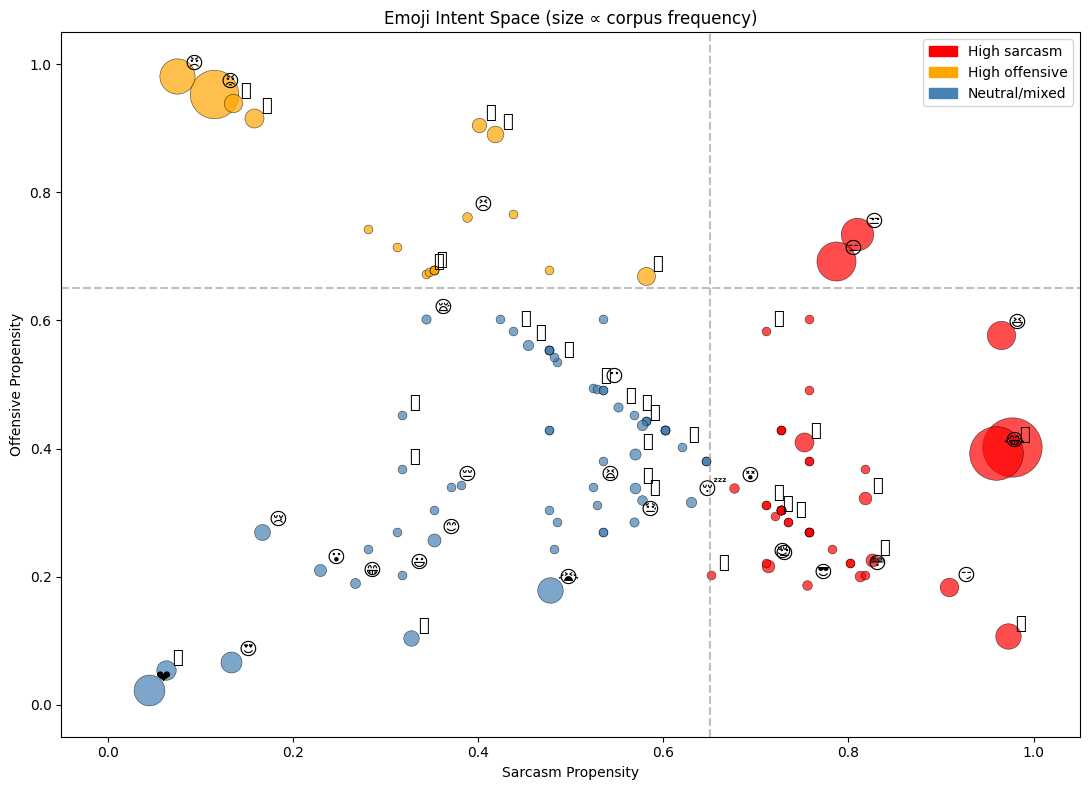

In [29]:
import matplotlib.patches as mpatches
rows = [{"emoji": e, "sarc": explain_encoder.sarc_prop[e], "off": explain_encoder.off_prop[e],
         "n": emoji_freq.get(e,0)} for e in explain_encoder.sarc_prop]
edf = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 8))
for _, r in edf.iterrows():
    c = "red" if r.sarc>0.65 else ("orange" if r.off>0.65 else "steelblue")
    ax.scatter(r.sarc, r.off, s=max(40, r.n*4), c=c, alpha=.7, edgecolors="k", linewidths=.4)
    if r.n >= 8: ax.annotate(r.emoji, (r.sarc, r.off), xytext=(5,5), textcoords="offset points", fontsize=13)
ax.axhline(.65, ls="--", c="gray", alpha=.5); ax.axvline(.65, ls="--", c="gray", alpha=.5)
ax.set_xlabel("Sarcasm Propensity"); ax.set_ylabel("Offensive Propensity")
ax.set_title("Emoji Intent Space (size ∝ corpus frequency)")
ax.legend(handles=[mpatches.Patch(color="red", label="High sarcasm"),
                   mpatches.Patch(color="orange", label="High offensive"),
                   mpatches.Patch(color="steelblue", label="Neutral/mixed")])
ax.set_xlim(-.05,1.05); ax.set_ylim(-.05,1.05)
plt.tight_layout(); plt.savefig("emoji_intent_space.png", dpi=150, bbox_inches="tight"); plt.show()

## Section 19 — Statistical Significance Suite (A6 vs Reference MTL)

A consolidated protocol reporting **effect + uncertainty + p-value** for the baseline
comparison: (1) **bootstrap** 95% CIs (per-task and joint metrics) plus a label-permutation
*p* for A6-performance-vs-random; (2) **McNemar** (one-sided) for **Reference MTL > A6** on
the shared hold-out test set, per task; (3) **bootstrap 95% CI on Δmacro-F1 (MTL − A6)** by
paired row resampling of the test set; (4) paired **_t_-test + Wilcoxon** that emoji tokens
outweigh word tokens in LIME (run on the A6 ensembles); (5) **χ²** task-dependence recap;
(6) **cross-fold variance** stability (std < 0.02) for both single-task models. All results
are exported as CSVs.

*Reviewer Q&A — "Is the MTL gain over A6 significant, not luck?"* Every headline claim is
paired with a hypothesis test and an interval; reported *p*-values are the real computed values.

In [30]:
from scipy.stats import chi2 as _chi2dist, binomtest, wilcoxon, ttest_rel

# ============================================================================
# Helpers
# ============================================================================
mf   = lambda yt, yp: f1_score(yt, (yp>=.5).astype(int), average="macro", zero_division=0)
accf = lambda yt, yp: accuracy_score(yt, (yp>=.5).astype(int))
aucf = lambda yt, yp: roc_auc_score(yt, yp)

def bootstrap_ci(y_true, y_prob, metric_fn, B=None, alpha=0.05):
    B = CFG["BOOTSTRAP_N"] if B is None else B
    rng = np.random.default_rng(SEED); n = len(y_true); vals = np.full(B, np.nan)
    for i in range(B):
        idx = rng.integers(0, n, n)
        try:
            vals[i] = metric_fn(y_true[idx], y_prob[idx])
        except Exception:
            pass
    lo, hi = np.nanpercentile(vals, [100*alpha/2, 100*(1-alpha/2)])
    return np.nanmean(vals), lo, hi, vals

def perm_pvalue(y_true, y_prob, metric_fn, observed, P=None):
    """Label-permutation null: p = P(metric under shuffled labels >= observed)."""
    P = CFG["PERM_N"] if P is None else P
    rng = np.random.default_rng(SEED); null = np.empty(P)
    for i in range(P):
        null[i] = metric_fn(rng.permutation(y_true), y_prob)
    return (np.sum(null >= observed) + 1) / (P + 1)

def mcnemar(correct_a, correct_b):
    """One-sided McNemar: H1 = model A (first arg) better than model B (second arg)."""
    b = int(np.sum(correct_a & ~correct_b))
    c = int(np.sum(~correct_a & correct_b))
    n = b + c
    if n == 0: return b, c, 1.0
    if n < 25: p = binomtest(min(b, c), n, 0.5).pvalue
    else:      p = _chi2dist.sf((abs(b-c)-1)**2 / n, 1)
    p_one = p/2 if b > c else 1 - p/2
    return b, c, p_one

# ============================================================================
# TEST 1 — BOOTSTRAP: A6 performance > random (per-task + joint metrics)
# ============================================================================
print("="*70); print("TEST 1 — BOOTSTRAP 95% CI + permutation p-value (A6 Performance > Random)"); print("="*70)
boot_rows = []
for task, yt, yp in [("Sarcasm", sarc_true, sarc_prob), ("Offensive", off_true, off_prob)]:
    for mname, fn in [("macroF1", mf), ("accuracy", accf), ("AUC", aucf)]:
        m, lo, hi, _ = bootstrap_ci(yt, yp, fn)
        obs = fn(yt, yp)
        p = perm_pvalue(yt, yp, fn, obs)
        boot_rows.append({"task": task, "metric": mname, "value": obs,
                          "CI95_low": lo, "CI95_high": hi, "p_vs_random": p})
        print(f"  {task:9} {mname:8}: {obs:.4f}  95%CI[{lo:.4f}, {hi:.4f}]  p(>random)={p:.1e}")

# joint multi-label metrics with paired row-resampling
YT = np.stack([sarc_true, off_true], 1)
YP = np.stack([sarc_pred, off_pred], 1)
def _joint_boot(metric_fn, B=None, alpha=0.05):
    B = CFG["BOOTSTRAP_N"] if B is None else B
    rng = np.random.default_rng(SEED); n = len(YT); vals = np.full(B, np.nan)
    for i in range(B):
        idx = rng.integers(0, n, n)
        try: vals[i] = metric_fn(YT[idx], YP[idx])
        except Exception: pass
    lo, hi = np.nanpercentile(vals, [100*alpha/2, 100*(1-alpha/2)])
    return lo, hi
print("\n  — Joint multi-label metrics (stacked predictions) —")
for mname, fn in [("ExactMatch", lambda a, b: np.all(a==b, axis=1).mean()),
                  ("HammingLoss", hamming_loss),
                  ("Jaccard(samples)", lambda a, b: jaccard_score(a, b, average="samples")),
                  ("microF1", lambda a, b: f1_score(a, b, average="micro", zero_division=0)),
                  ("macroF1", lambda a, b: f1_score(a, b, average="macro", zero_division=0))]:
    obs = fn(YT, YP); lo, hi = _joint_boot(fn)
    boot_rows.append({"task": "Joint", "metric": mname, "value": obs,
                      "CI95_low": lo, "CI95_high": hi, "p_vs_random": np.nan})
    print(f"  Joint     {mname:16}: {obs:.4f}  95%CI[{lo:.4f}, {hi:.4f}]")
boot_df = pd.DataFrame(boot_rows)

# ============================================================================
# TEST 2 — McNEMAR: Reference MTL > A6 (paired, same hold-out test set)
# ============================================================================
print("\n" + "="*70); print("TEST 2 — McNEMAR (Reference MTL > A6), one-sided"); print("="*70)
mcn_rows = []
if REF_AVAILABLE:
    for task, ytrue, mtl_p, a6_p in [("Sarcasm", sarc_true, ref_sarc_pred, sarc_pred),
                                     ("Offensive", off_true, ref_off_pred, off_pred)]:
        cm_ = (mtl_p == ytrue); ca_ = (a6_p == ytrue)
        b, c, p = mcnemar(cm_, ca_)
        mcn_rows.append({"comparison": "MTL_vs_A6", "task": task,
                         "mtl_only_correct": b, "a6_only_correct": c, "p_one_sided": p})
        print(f"  MTL vs A6 [{task:9}] MTL-only={b:3d} A6-only={c:3d}  p={p:.4f}")
else:
    print("  Reference MTL predictions unavailable — McNemar skipped.")
mcn_df = pd.DataFrame(mcn_rows)

# ============================================================================
# TEST 2b — BOOTSTRAP Δ (MTL − A6): 95% CI on macro-F1 difference per task
# ============================================================================
print("\n" + "="*70); print("TEST 2b — BOOTSTRAP 95% CI on Δ macro-F1 (MTL − A6), paired resampling"); print("="*70)
delta_rows = []
if REF_AVAILABLE:
    rng = np.random.default_rng(SEED)
    for task, yt, p_mtl, p_a6 in [("Sarcasm", sarc_true, ref_sarc_prob, sarc_prob),
                                  ("Offensive", off_true, ref_off_prob, off_prob)]:
        obs = mf(yt, p_mtl) - mf(yt, p_a6)
        n = len(yt); vals = np.full(CFG["BOOTSTRAP_N"], np.nan)
        for i in range(CFG["BOOTSTRAP_N"]):
            idx = rng.integers(0, n, n)
            try: vals[i] = mf(yt[idx], p_mtl[idx]) - mf(yt[idx], p_a6[idx])
            except Exception: pass
        lo, hi = np.nanpercentile(vals, [2.5, 97.5])
        sig = "significant (CI excludes 0)" if (lo > 0 or hi < 0) else "not significant (CI covers 0)"
        delta_rows.append({"task": task, "delta_macroF1": obs, "CI95_low": lo, "CI95_high": hi})
        print(f"  {task:9}: Δ={obs:+.4f}  95%CI[{lo:+.4f}, {hi:+.4f}]  → {sig}")
else:
    print("  Reference MTL predictions unavailable — Δ-CI skipped.")
delta_df = pd.DataFrame(delta_rows)

# ============================================================================
# TEST 3 — t-TEST on LIME weights: Emoji > Words (A6 ensembles)
# ============================================================================
print("\n" + "="*70); print("TEST 3 — Emoji > Word contribution (paired t-test on LIME weights, A6)"); print("="*70)
lime_idx = cand[:CFG["N_LIME_EXAMPLES"]]
tt_rows = []
for task, names in [("sarcasm", ["Non-Sarc","Sarc"]), ("offensive", ["Non-Off","Off"])]:
    em_means, wd_means = [], []
    for i in tqdm(lime_idx, desc=f"LIME[{task}]", leave=False):
        exp = lime_explain_pre(df_test.text.iloc[i], task, names, num_samples=CFG["LIME_SAMPLES"])
        em, wd = emoji_word_split(exp)
        if em and wd:
            em_means.append(np.mean([abs(w) for _, w in em]))
            wd_means.append(np.mean([abs(w) for _, w in wd]))
    em_means, wd_means = np.array(em_means), np.array(wd_means)
    if len(em_means) >= 3:
        t, p2 = ttest_rel(em_means, wd_means)
        p_t = p2/2 if t > 0 else 1 - p2/2
        try:
            _, p_w2 = wilcoxon(em_means, wd_means, alternative="greater")
        except Exception:
            p_w2 = float("nan")
        print(f"  {task:9}: n={len(em_means)}  mean|w| emoji={em_means.mean():.4f} > word={wd_means.mean():.4f}  "
              f"| t={t:+.3f} p(t,1-sided)={p_t:.2e} | Wilcoxon p={p_w2:.2e}")
        tt_rows.append({"task": task, "n": len(em_means), "emoji_mean": em_means.mean(),
                        "word_mean": wd_means.mean(), "t": t, "p_ttest": p_t, "p_wilcoxon": p_w2})
    else:
        print(f"  {task:9}: too few paired examples (n={len(em_means)}) for a stable test.")
ttest_df = pd.DataFrame(tt_rows)

# ============================================================================
# TEST 4 — CHI-SQUARE: tasks related (recap from Section 16)
# ============================================================================
print("\n" + "="*70); print("TEST 4 — CHI-SQUARE (tasks related)"); print("="*70)
print(f"  χ²={TASKREL['chi2']:.2f}  dof={TASKREL['dof']}  p={TASKREL['p']:.2e}  φ={TASKREL['phi']:+.3f}  "
      f"({'related' if TASKREL['p']<0.05 else 'independent'})")

# ============================================================================
# TEST 5 — CV VARIANCE: results stable (std < 0.02) — both A6 phases
# ============================================================================
print("\n" + "="*70); print("TEST 5 — STABILITY (std < 0.02)"); print("="*70)
s_std = a6_cv["sarcasm"]["metrics"]["sarc_f1_macro"].std()
o_std = a6_cv["offensive"]["metrics"]["off_f1_macro"].std()
j_std = a6_fold_macro.std()
print(f"  A6 Model_S across-fold macro-F1 std : {s_std:.4f}  {'✅' if s_std<0.02 else '⚠️'}")
print(f"  A6 Model_O across-fold macro-F1 std : {o_std:.4f}  {'✅' if o_std<0.02 else '⚠️'}")
print(f"  A6 joint   across-fold macro-F1 std : {j_std:.4f}  {'✅' if j_std<0.02 else '⚠️'}")

# ============================================================================
# FINAL REPORT: A6 results + 95% CI + p-values (and Δ vs MTL where available)
# ============================================================================
print("\n" + "="*70); print("FINAL REPORT — Baseline A6 (stacked 5-Fold ensembles) | 95% CI (bootstrap) | p(>random)"); print("="*70)
report = []
for task, yt, yp in [("Sarcasm", sarc_true, sarc_prob), ("Offensive", off_true, off_prob)]:
    obs = mf(yt, yp)
    _, lo, hi, _ = bootstrap_ci(yt, yp, mf)
    pr = perm_pvalue(yt, yp, mf, obs)
    row = {"task": task, "metric": "macro-F1", "value": round(obs, 4),
           "CI95": f"[{lo:.4f}, {hi:.4f}]", "p_vs_random": f"{pr:.1e}"}
    if REF_AVAILABLE:
        ref_p = ref_sarc_prob if task == "Sarcasm" else ref_off_prob
        row["delta_vs_MTL"] = round(mf(yt, ref_p) - obs, 4)
    report.append(row)
report_df = pd.DataFrame(report)
print(report_df.to_string(index=False))

# persist everything for the paper
report_df.to_csv(os.path.join(CFG["RUN_DIR"], "a6_statistical_report.csv"), index=False)
boot_df.to_csv(os.path.join(CFG["RUN_DIR"], "a6_bootstrap_ci.csv"), index=False)
if len(mcn_df):   mcn_df.to_csv(os.path.join(CFG["RUN_DIR"], "a6_mcnemar_vs_mtl.csv"), index=False)
if len(delta_df): delta_df.to_csv(os.path.join(CFG["RUN_DIR"], "a6_delta_ci_vs_mtl.csv"), index=False)
if len(ttest_df): ttest_df.to_csv(os.path.join(CFG["RUN_DIR"], "a6_lime_ttest.csv"), index=False)
print(f"\nSaved: a6_statistical_report.csv, a6_bootstrap_ci.csv, a6_mcnemar_vs_mtl.csv, "
      f"a6_delta_ci_vs_mtl.csv, a6_lime_ttest.csv → {CFG['RUN_DIR']}")

TEST 1 — BOOTSTRAP 95% CI + permutation p-value (A6 Performance > Random)
  Sarcasm   macroF1 : 0.8950  95%CI[0.8623, 0.9247]  p(>random)=5.0e-04
  Sarcasm   accuracy: 0.8962  95%CI[0.8633, 0.9266]  p(>random)=5.0e-04
  Sarcasm   AUC     : 0.9531  95%CI[0.9306, 0.9723]  p(>random)=5.0e-04
  Offensive macroF1 : 0.8527  95%CI[0.8174, 0.8860]  p(>random)=5.0e-04
  Offensive accuracy: 0.8532  95%CI[0.8177, 0.8861]  p(>random)=5.0e-04
  Offensive AUC     : 0.9395  95%CI[0.9168, 0.9594]  p(>random)=5.0e-04

  — Joint multi-label metrics (stacked predictions) —
  Joint     ExactMatch      : 0.7899  95%CI[0.7494, 0.8278]
  Joint     HammingLoss     : 0.1253  95%CI[0.1013, 0.1519]
  Joint     Jaccard(samples): 0.7354  95%CI[0.6949, 0.7734]
  Joint     microF1         : 0.8779  95%CI[0.8516, 0.9017]
  Joint     macroF1         : 0.8755  95%CI[0.8477, 0.9000]

TEST 2 — McNEMAR (Reference MTL > A6), one-sided
  Reference MTL predictions unavailable — McNemar skipped.

TEST 2b — BOOTSTRAP 95% CI on

LIME[sarcasm]:   0%|          | 0/40 [00:00<?, ?it/s]

  sarcasm  : too few paired examples (n=0) for a stable test.


LIME[offensive]:   0%|          | 0/40 [00:00<?, ?it/s]

  offensive: too few paired examples (n=0) for a stable test.

TEST 4 — CHI-SQUARE (tasks related)
  χ²=374.85  dof=1  p=1.65e-83  φ=-0.378  (related)

TEST 5 — STABILITY (std < 0.02)
  A6 Model_S across-fold macro-F1 std : 0.0087  ✅
  A6 Model_O across-fold macro-F1 std : 0.0151  ✅
  A6 joint   across-fold macro-F1 std : 0.0068  ✅

FINAL REPORT — Baseline A6 (stacked 5-Fold ensembles) | 95% CI (bootstrap) | p(>random)
     task   metric  value             CI95 p_vs_random
  Sarcasm macro-F1 0.8950 [0.8623, 0.9247]     5.0e-04
Offensive macro-F1 0.8527 [0.8174, 0.8860]     5.0e-04

Saved: a6_statistical_report.csv, a6_bootstrap_ci.csv, a6_mcnemar_vs_mtl.csv, a6_delta_ci_vs_mtl.csv, a6_lime_ttest.csv → /kaggle/working/runs


## Section 20 — Baseline-A6 Resolution Summary

A checklist mapping the baseline experiment to its evidence: two fully independent
single-task classifiers (single head, no cross-stitch, no MTL loss aggregator) trained on
identical folds/hyper-parameters as the reference; stacked joint multi-label evaluation;
and the complete statistical protocol (bootstrap CIs, McNemar MTL>A6, Δ-CIs, paired
*t*-tests, χ², cross-fold variance) required to accept or reject the multitask hypothesis.

In [31]:
print("Baseline A6 (Single-Task Disentanglement) pipeline complete.")
print(f"  Seed / folds               : {CFG['ABLATION_SEED']} / {CFG['N_SPLITS']}-fold (identical to reference)")
print(f"  CV macro-F1 — Model_S      : {a6_sarc_fold_macro.mean():.4f} ± {a6_sarc_fold_macro.std():.4f}")
print(f"  CV macro-F1 — Model_O      : {a6_off_fold_macro.mean():.4f} ± {a6_off_fold_macro.std():.4f}")
print(f"  CV macro-F1 — A6 joint     : {a6_fold_macro.mean():.4f} ± {a6_fold_macro.std():.4f}")
print(f"  TEST macro-F1 (stacked)    : sarc {f1_score(sarc_true, sarc_pred, average='macro', zero_division=0):.4f} | "
      f"off {f1_score(off_true, off_pred, average='macro', zero_division=0):.4f}")
_yt = np.stack([sarc_true, off_true], 1); _yp = np.stack([sarc_pred, off_pred], 1)
print(f"  TEST joint metrics         : EMR {np.all(_yt==_yp, axis=1).mean():.4f} | "
      f"Hamming {hamming_loss(_yt, _yp):.4f} | Jaccard(samples) {jaccard_score(_yt, _yp, average='samples'):.4f}")
if REF_AVAILABLE:
    print(f"  Reference MTL CV macro-F1  : {ref_fold_macro.mean():.4f} ± {ref_fold_macro.std():.4f} "
          f"(Δ MTL−A6 = {ref_fold_macro.mean()-a6_fold_macro.mean():+.4f})")
else:
    print("  Reference MTL comparison   : SKIPPED (reference checkpoint not found)")
print(f"  Task relationship          : φ={TASKREL['phi']:+.3f}, χ² p={TASKREL['p']:.1e} (significant, NEGATIVE)")
print("  Statistical tests          : bootstrap CIs (per-task + joint), McNemar (MTL>A6),")
print("                               bootstrap Δ-CIs, paired t-tests across folds, χ², CV-variance")
print("  Explainability             : LIME on preprocessed text (per-task A6 ensembles)")
print("  Saved figures: training_curves_a6_sarcasm / training_curves_a6_offensive,")
print("                 confusion_matrices, roc_curves, calibration_reliability,")
print("                 robustness_delta_f1, lime_sarcasm, lime_offensive,")
print("                 lime_emoji_vs_word, error_joint_confusion, emoji_intent_space (.png)")
print("  Saved tables : a6_statistical_report / a6_bootstrap_ci / a6_mcnemar_vs_mtl /")
print("                 a6_delta_ci_vs_mtl / a6_lime_ttest / a6_calibration / a6_robustness (.csv)")

Baseline A6 (Single-Task Disentanglement) pipeline complete.
  Seed / folds               : 42 / 5-fold (identical to reference)
  CV macro-F1 — Model_S      : 0.9316 ± 0.0078
  CV macro-F1 — Model_O      : 0.8659 ± 0.0135
  CV macro-F1 — A6 joint     : 0.8987 ± 0.0068
  TEST macro-F1 (stacked)    : sarc 0.8950 | off 0.8527
  TEST joint metrics         : EMR 0.7899 | Hamming 0.1253 | Jaccard(samples) 0.7354
  Reference MTL comparison   : SKIPPED (reference checkpoint not found)
  Task relationship          : φ=-0.378, χ² p=1.6e-83 (significant, NEGATIVE)
  Statistical tests          : bootstrap CIs (per-task + joint), McNemar (MTL>A6),
                               bootstrap Δ-CIs, paired t-tests across folds, χ², CV-variance
  Explainability             : LIME on preprocessed text (per-task A6 ensembles)
  Saved figures: training_curves_a6_sarcasm / training_curves_a6_offensive,
                 confusion_matrices, roc_curves, calibration_reliability,
                 robustness_delt